<a href="https://colab.research.google.com/github/luisferojedat/claimai-policy-analyzer/blob/main/actividad4_modelos_de_machine_learning_luis_ojeda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Script de verificación de entorno y limpieza final
import os

print("--- Verificación de Entorno ---")
if 'google.colab' in str(get_ipython()):
    print("Ejecutando en: Google Colab")
else:
    print("Ejecutando en: Entorno Local (Jupyter/VS Code)")

# Verificar presencia del dataset para evitar errores en 'Run All'
if os.path.exists("galaxy_zoo2_trimmed.csv"):
    print("✔ Dataset detectado correctamente.")
else:
    print("⚠ Dataset no detectado en el directorio actual. Asegúrese de subirlo para la ejecución completa.")

print("\nEl cuaderno está listo para 'Restart and Run All'.")

--- Verificación de Entorno ---
Ejecutando en: Google Colab
✔ Dataset detectado correctamente.

El cuaderno está listo para 'Restart and Run All'.


# **Clasificación de Galaxias con Machine Learning y PCA**

Este cuaderno implementa un flujo completo de Machine Learning para clasificar galaxias en espirales o elípticas.

#Estudiante: **Luis Fernando Ojeda Tinoco**

#Con este trabajo logramos demostrar que, a partir de una base de datos observacional de galaxias, es posible construir un modelo de Machine Learning capaz de clasificar automáticamente galaxias espirales y elípticas usando variables medibles como brillo, color, tamaño, concentración y forma.

En términos simples: convertimos una base de datos científica en una herramienta de clasificación predictiva.

# 1. Carga de Datos

### Carga del archivo CSV

Para cargar el dataset, se utilizará `files.upload()` de `google.colab` que permite al usuario subir el archivo directamente al entorno de Colab. Una vez subido, se leerá con pandas.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import os
from pathlib import Path
from google.colab import files
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# 1.CARGA DEL ARCHIVO CSV
# Compatible con Google Colab y Jupyter Notebook
# ============================================================

IN_COLAB = 'google.colab' in str(get_ipython())
csv_filename = "galaxy_zoo2_trimmed.csv"

if IN_COLAB:
    print(f"Por favor, sube el archivo: {csv_filename}")
    uploaded = files.upload()
    actual_filename = list(uploaded.keys())[0]
    if actual_filename != csv_filename:
        print(f"Advertencia: El archivo subido se guardó como '{actual_filename}' en lugar de '{csv_filename}'. Se usará '{actual_filename}'.")
    df = pd.read_csv(io.BytesIO(uploaded[actual_filename]))
else:
    csv_path = Path(csv_filename)
    if not csv_path.exists():
        raise FileNotFoundError(f"No se encontró el archivo '{csv_filename}'")
    df = pd.read_csv(csv_path)

print("Archivo cargado correctamente.")
print(f"Dimensiones del dataset: {df.shape}")

Por favor, sube el archivo: galaxy_zoo2_trimmed.csv


Saving galaxy_zoo2_trimmed.csv to galaxy_zoo2_trimmed (4).csv
Advertencia: El archivo subido se guardó como 'galaxy_zoo2_trimmed (4).csv' en lugar de 'galaxy_zoo2_trimmed.csv'. Se usará 'galaxy_zoo2_trimmed (4).csv'.
Archivo cargado correctamente.
Dimensiones del dataset: (11787, 14)


### 1.1 Revisión inicial de calidad de datos

Antes de proceder con el análisis exploratorio y el modelado, es fundamental realizar una inspección técnica del dataset para verificar su integridad. Esto incluye:
*   Estructura general y dimensiones.
*   Tipos de datos por columna.
*   Estadísticas descriptivas básicas.
*   Detección de valores nulos y registros duplicados.

In [3]:
print('--- Resumen de Datos ---')
display(df.head())
print('\n--- Información Técnica ---')
df.info()
print(f'\nDimensiones: {df.shape}')
print('\n--- Estadísticas Descriptivas ---')
display(df.describe().T)
print('\n--- Calidad de Datos ---')
print(f'Valores nulos totales: {df.isnull().sum().sum()}')
print(f'Filas duplicadas: {df.duplicated().sum()}')
print(f'Columnas: {df.columns.tolist()}')

--- Resumen de Datos ---


,petromag_u,petromag_g,petromag_r,petromag_i,petromag_z,petror50_r,petror90_r,concentration,devab_r,u_g,g_r,r_i,i_z,target
0,19.027740,17.487066,16.775278,16.350470,16.062790,2.494026,6.790056,2.722528,0.616003,1.540674,0.711788,0.424808,0.287680,elliptical
1,18.228308,17.009373,16.416782,16.021749,15.785794,2.617994,5.425934,2.072554,0.700000,1.218935,0.592591,0.395033,0.235955,elliptical
2,19.258045,17.178354,16.149349,15.692777,15.374460,2.536915,7.550951,2.976430,0.826899,2.079691,1.029005,0.456572,0.318317,elliptical
3,18.826595,16.976576,16.117329,15.664383,15.379037,2.529984,7.387836,2.920112,0.661354,1.850019,0.859247,0.452946,0.285346,elliptical
4,18.632311,17.419504,16.682373,16.309332,16.037376,3.065978,6.175660,2.014255,0.532566,1.212807,0.737131,0.373041,0.271956,elliptical



--- Información Técnica ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11787 entries, 0 to 11786
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   petromag_u     11787 non-null  float64
 1   petromag_g     11787 non-null  float64
 2   petromag_r     11787 non-null  float64
 3   petromag_i     11787 non-null  float64
 4   petromag_z     11787 non-null  float64
 5   petror50_r     11787 non-null  float64
 6   petror90_r     11787 non-null  float64
 7   concentration  11787 non-null  float64
 8   devab_r        11787 non-null  float64
 9   u_g            11787 non-null  float64
 10  g_r            11787 non-null  float64
 11  r_i            11787 non-null  float64
 12  i_z            11787 non-null  float64
 13  target         11787 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.3+ MB

Dimensiones: (11787, 14)

--- Estadísticas Descriptivas ---


,count,mean,std,min,25%,50%,75%,max
petromag_u,11787.0,18.821790,0.899913,14.346013,18.297297,18.944880,19.472777,21.945023
petromag_g,11787.0,17.165932,0.791078,12.771928,16.788728,17.361563,17.735371,18.949085
petromag_r,11787.0,16.331495,0.721533,12.178217,16.012561,16.549639,16.866133,17.706539
petromag_i,11787.0,15.935322,0.714976,11.837103,15.622070,16.148109,16.460490,17.266369
petromag_z,11787.0,15.671572,0.704404,11.687765,15.360709,15.863113,16.172187,16.954662
petror50_r,11787.0,3.019179,1.513397,0.962538,2.049916,2.579823,3.479284,19.713860
petror90_r,11787.0,8.173440,3.554434,3.001457,5.807772,7.318419,9.586545,36.452015
concentration,11787.0,2.788012,0.414232,1.686244,2.467863,2.872812,3.121837,5.582179
devab_r,11787.0,0.698450,0.179868,0.123314,0.579447,0.725421,0.839959,0.999991
u_g,11787.0,1.655858,0.347793,0.002761,1.408119,1.690868,1.869085,3.986334



--- Calidad de Datos ---
Valores nulos totales: 0
Filas duplicadas: 0
Columnas: ['petromag_u', 'petromag_g', 'petromag_r', 'petromag_i', 'petromag_z', 'petror50_r', 'petror90_r', 'concentration', 'devab_r', 'u_g', 'g_r', 'r_i', 'i_z', 'target']


## 1.2 Separación de variables predictoras y objetivo

Definimos `X` con las variables numéricas y preparamos `y` para la codificación. Es fundamental que la variable objetivo sea numérica para que todos los algoritmos puedan procesarla correctamente.

In [4]:
from sklearn.preprocessing import LabelEncoder

numeric_cols = [
    'petromag_u', 'petromag_g', 'petromag_r', 'petromag_i', 'petromag_z',
    'petror50_r', 'petror90_r', 'concentration', 'devab_r',
    'u_g', 'g_r', 'r_i', 'i_z'
]
target_col = 'target'

X = df[numeric_cols]

# Codificación única y definitiva de la variable objetivo
encoder = LabelEncoder()
y = encoder.fit_transform(df[target_col])
target_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

print(f"Variables predictoras (X): {len(numeric_cols)}")
print(f"Mapeo de target (y): {target_mapping}")
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Variables predictoras (X): 13
Mapeo de target (y): {'elliptical': np.int64(0), 'spiral': np.int64(1)}
Dimensiones de X: (11787, 13)
Dimensiones de y: (11787,)


---

# 2. Exploración de Datos (EDA)

## 2.1 Distribución de la variable objetivo

Cantidad de observaciones por clase:
 target
elliptical    9404
spiral        2383
Name: count, dtype: int64

Porcentaje de cada clase:
 target
elliptical    79.782812
spiral        20.217188
Name: proportion, dtype: float64


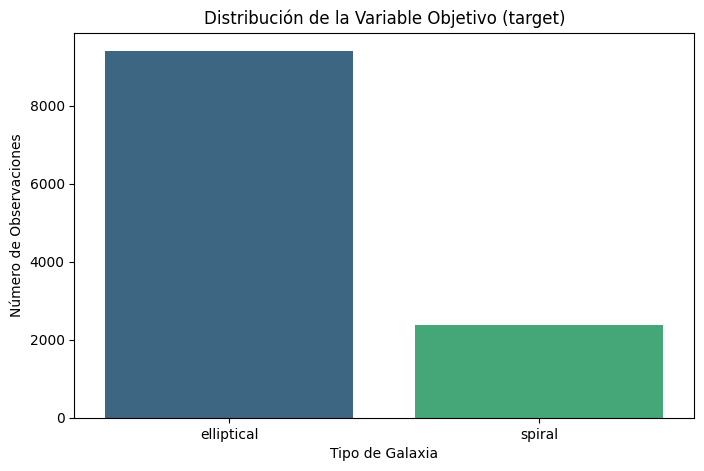


Las clases están desbalanceadas. La clase mayoritaria representa un 79.78% de los datos.
Esta revisión es importante porque los modelos entrenados con datasets desbalanceados pueden estar sesgados hacia la clase mayoritaria, teniendo un buen rendimiento en esa clase pero un mal rendimiento en la minoritaria. Esto puede llevar a métricas engañosas (ej. alta Accuracy) si no se utilizan estrategias adecuadas (ej. estratificación, re-muestreo, métricas como F1-score).


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cantidad de observaciones por clase
class_counts = df['target'].value_counts()
print("Cantidad de observaciones por clase:\n", class_counts)

# Porcentaje de cada clase
class_percentages = df['target'].value_counts(normalize=True) * 100
print("\nPorcentaje de cada clase:\n", class_percentages)

# Gráfico de barras de la variable target
plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis', legend=False)
plt.title('Distribución de la Variable Objetivo (target)')
plt.xlabel('Tipo de Galaxia')
plt.ylabel('Número de Observaciones')
plt.show()

# Explicación del balance de clases
if class_percentages.max() - class_percentages.min() > 10: # Umbral arbitrario para considerar desbalance
    print("\nLas clases están desbalanceadas. La clase mayoritaria representa un {:.2f}% de los datos.".format(class_percentages.max()))
    print("Esta revisión es importante porque los modelos entrenados con datasets desbalanceados pueden estar sesgados hacia la clase mayoritaria, teniendo un buen rendimiento en esa clase pero un mal rendimiento en la minoritaria. Esto puede llevar a métricas engañosas (ej. alta Accuracy) si no se utilizan estrategias adecuadas (ej. estratificación, re-muestreo, métricas como F1-score).")
else:
    print("\nLas clases parecen estar razonablemente equilibradas. Esto es favorable para el entrenamiento de modelos, ya que reduce el riesgo de sesgo hacia una clase específica.")

## 2.2 Estadísticos descriptivos

In [6]:
print("Interpretación de las variables y sus escalas:")
print("  * **Magnitudes:** Brillo en diferentes bandas (petromag_u a petromag_z).")
print("  * **Radios:** Tamaño angular (petror50_r, petror90_r).")
print("  * **Forma:** Concentración y relación de ejes (devab_r).")
print("  * **Colores:** Índices calculados como diferencias (u_g, g_r, r_i e i_z).")

Interpretación de las variables y sus escalas:
  * **Magnitudes:** Brillo en diferentes bandas (petromag_u a petromag_z).
  * **Radios:** Tamaño angular (petror50_r, petror90_r).
  * **Forma:** Concentración y relación de ejes (devab_r).
  * **Colores:** Índices calculados como diferencias (u_g, g_r, r_i e i_z).


## 2.3 Correlaciones y redundancia

Matriz de correlación de las variables numéricas:


,petromag_u,petromag_g,petromag_r,petromag_i,petromag_z,petror50_r,petror90_r,concentration,devab_r,u_g,g_r,r_i,i_z
petromag_u,1.000000,0.923364,0.820540,0.780166,0.721105,-0.664265,-0.593838,0.370302,0.078620,0.487246,0.662121,0.521672,0.547662
petromag_g,0.923364,1.000000,0.965960,0.942962,0.905330,-0.709254,-0.712053,0.180796,0.034136,0.114636,0.450193,0.346958,0.400739
petromag_r,0.820540,0.965960,1.000000,0.995865,0.980571,-0.689702,-0.758441,0.005310,-0.015669,-0.073995,0.203876,0.144917,0.234015
petromag_i,0.780166,0.942962,0.995865,1.000000,0.991885,-0.668820,-0.756856,-0.044658,-0.021710,-0.126150,0.131114,0.054428,0.178938
petromag_z,0.721105,0.905330,0.980571,0.991885,1.000000,-0.616287,-0.729221,-0.117430,-0.027414,-0.193373,0.041488,-0.025288,0.052402


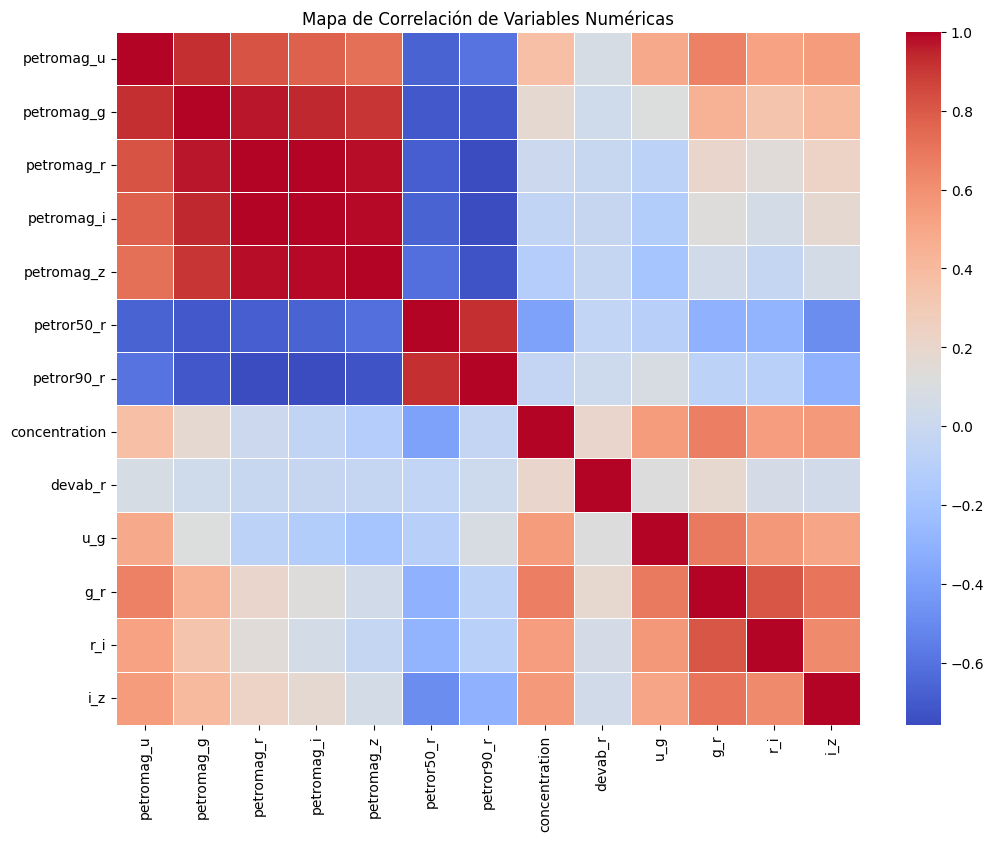


Identificación de variables altamente correlacionadas y redundancia:
Se identificaron los siguientes pares de variables con alta correlación (abs > 0.85):


,,0
petromag_r,petromag_i,0.995865
petromag_i,petromag_r,0.995865
petromag_z,petromag_i,0.991885
petromag_i,petromag_z,0.991885
petromag_z,petromag_r,0.980571
petromag_r,petromag_z,0.980571
petromag_g,petromag_r,0.965960
petromag_r,petromag_g,0.965960
petromag_i,petromag_g,0.942962
petromag_g,petromag_i,0.942962


La alta correlación entre estas variables sugiere que existe redundancia. Por ejemplo, las magnitudes fotométricas (`petromag_u` a `petromag_z`) están fuertemente correlacionadas entre sí, lo cual es esperable ya que miden el brillo de la galaxia en bandas adyacentes del espectro. De manera similar, los radios petrosianos (`petror50_r` y `petror90_r`) también muestran una alta correlación al ser medidas relacionadas con el tamaño global de la galaxia. Esta redundancia implica que estas variables están proporcionando información similar al modelo.

Implicaciones de la multicolinealidad para modelos lineales y PCA:
**Modelos Lineales (ej. Regresión Logística):** La multicolinealidad puede causar inestabilidad en los coeficientes, dificultando su interpretación y su estimación precisa. Sin embargo, no necesariamente afecta la capacidad predictiva general del modelo.
**PCA (Análisis de Componentes Principales):** PCA es particularmente útil en presencia de multicolinealidad. Al transformar

In [7]:
# Calcular la matriz de correlación de las variables numéricas
corr_matrix = df[numeric_cols].corr()

print("Matriz de correlación de las variables numéricas:")
display(corr_matrix.head())

# Crear un mapa de calor
plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Mapa de Correlación de Variables Numéricas")
plt.show()

print("\nIdentificación de variables altamente correlacionadas y redundancia:")
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1] # Excluir la correlación de una variable consigo misma
high_corr = corr_pairs[corr_pairs > 0.85] # Umbral de 0.85 para alta correlación

if not high_corr.empty:
    print("Se identificaron los siguientes pares de variables con alta correlación (abs > 0.85):")
    display(high_corr)
    print("La alta correlación entre estas variables sugiere que existe redundancia. Por ejemplo, las magnitudes fotométricas (`petromag_u` a `petromag_z`) están fuertemente correlacionadas entre sí, lo cual es esperable ya que miden el brillo de la galaxia en bandas adyacentes del espectro. De manera similar, los radios petrosianos (`petror50_r` y `petror90_r`) también muestran una alta correlación al ser medidas relacionadas con el tamaño global de la galaxia. Esta redundancia implica que estas variables están proporcionando información similar al modelo.")
else:
    print("No se identificaron pares de variables con alta correlación (abs > 0.85).")

print("\nImplicaciones de la multicolinealidad para modelos lineales y PCA:")
print("**Modelos Lineales (ej. Regresión Logística):** La multicolinealidad puede causar inestabilidad en los coeficientes, dificultando su interpretación y su estimación precisa. Sin embargo, no necesariamente afecta la capacidad predictiva general del modelo.")
print("**PCA (Análisis de Componentes Principales):** PCA es particularmente útil en presencia de multicolinealidad. Al transformar las variables originales en componentes principales ortogonales, PCA efectivamente elimina la redundancia y concentra la varianza compartida en un número menor de dimensiones. Esto es beneficioso para la reducción de dimensionalidad y para mejorar la estabilidad de modelos posteriores.")

## 2.4 Distribución de variables por clase

Boxplots de variables numéricas por tipo de galaxia:


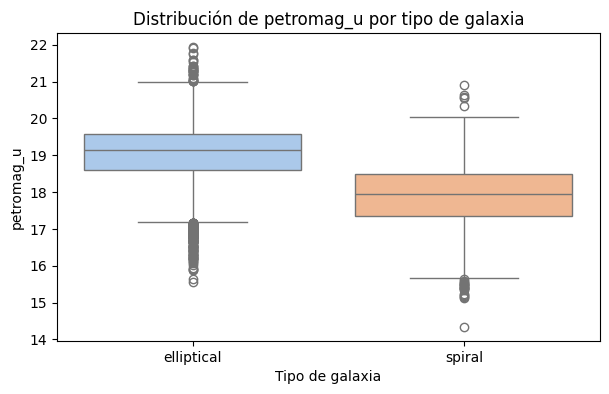

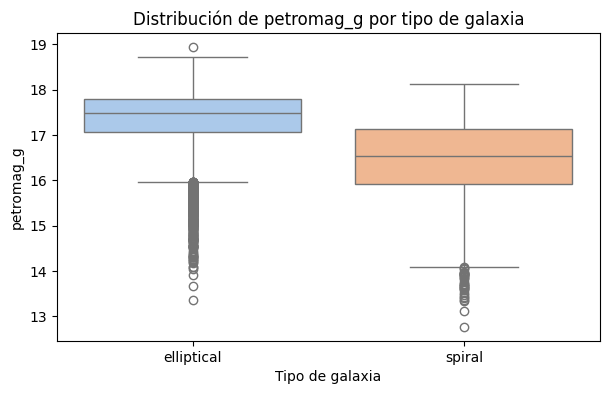

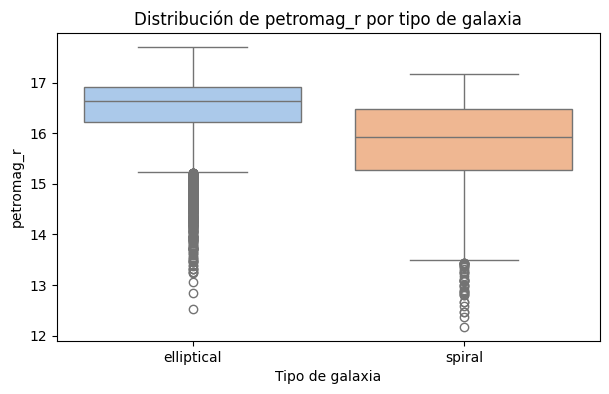

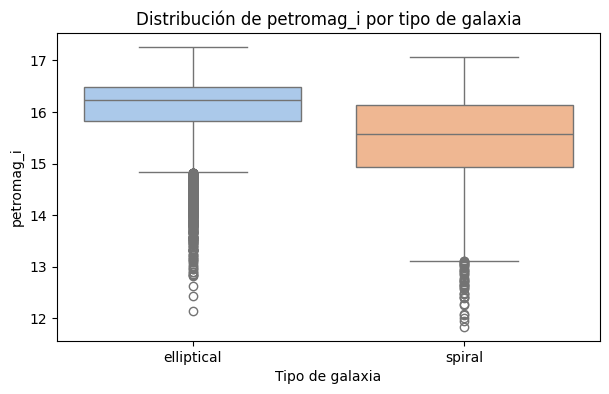

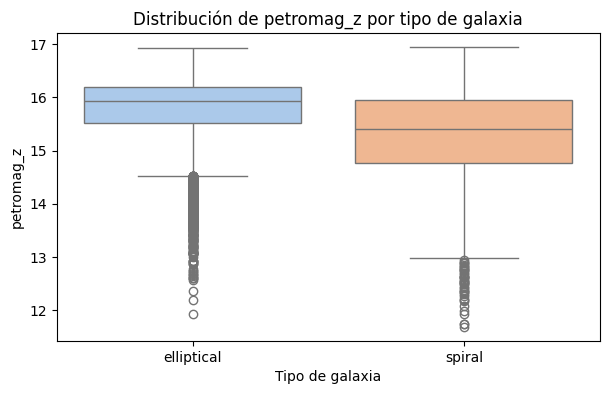

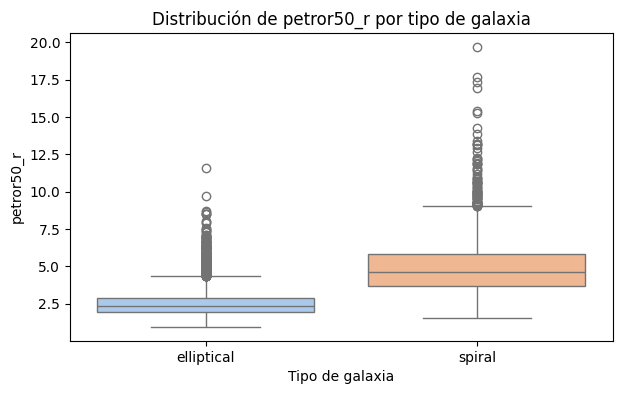

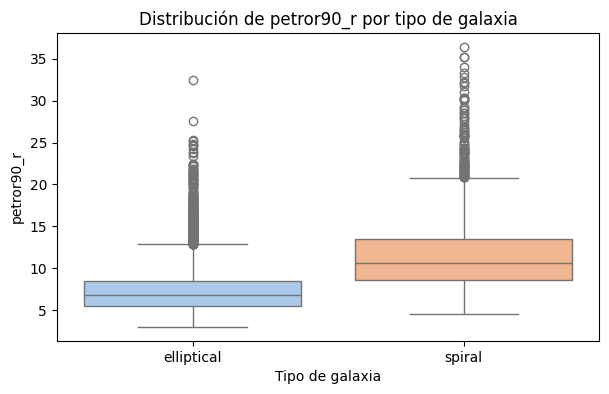

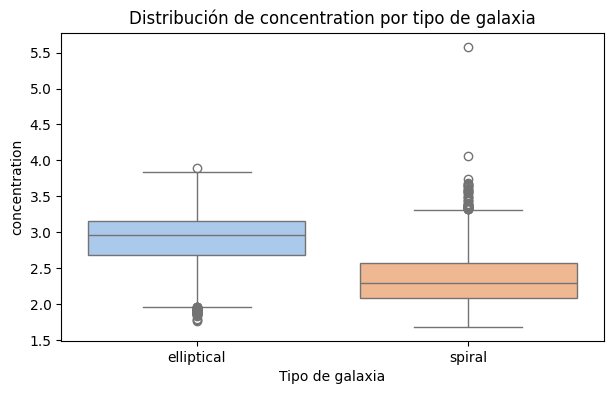

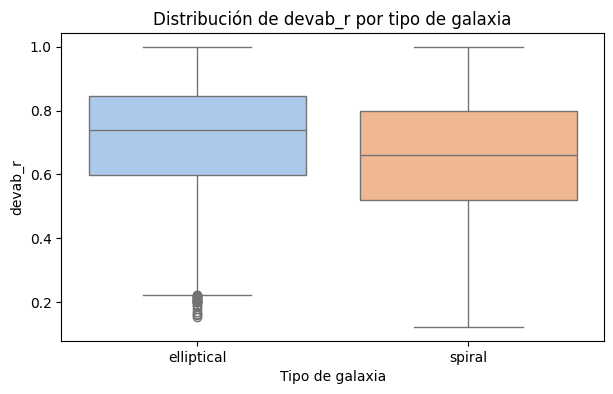

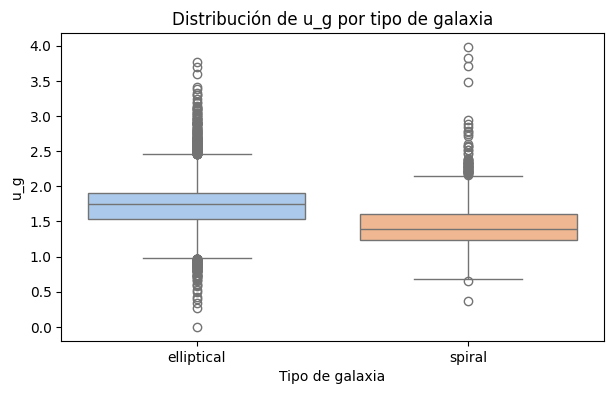

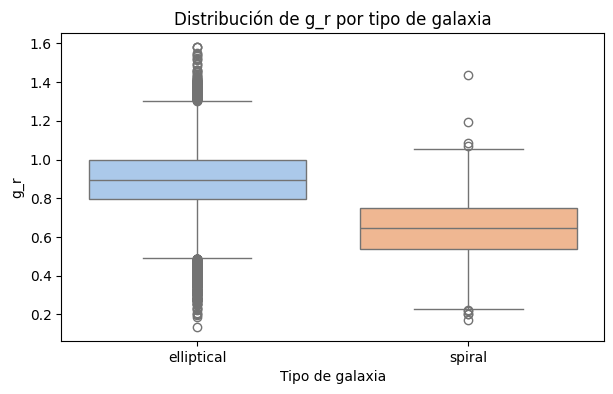

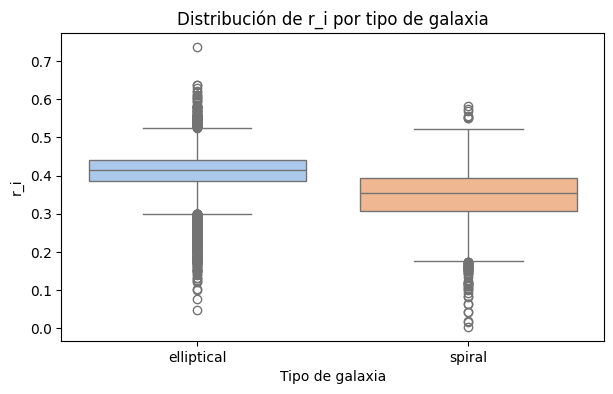

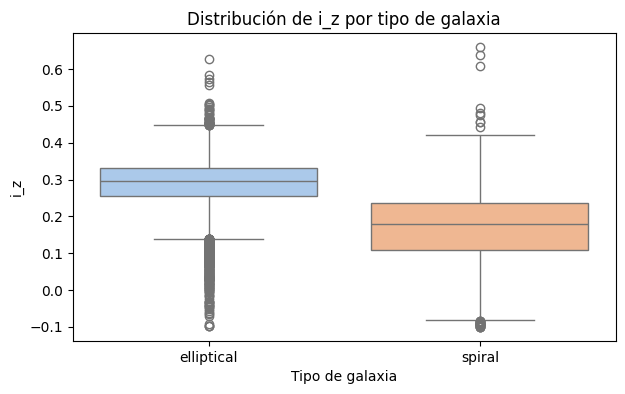


Histogramas y KDEs de variables numéricas por tipo de galaxia:


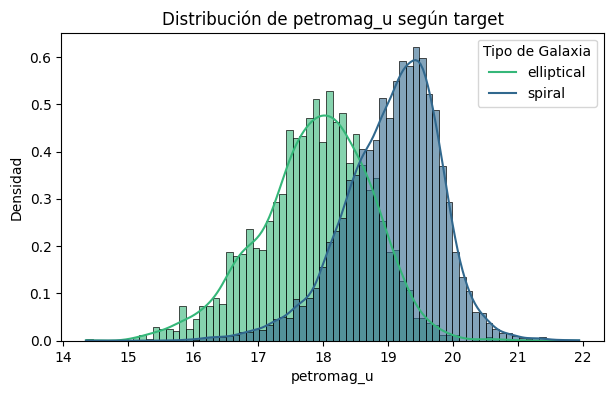

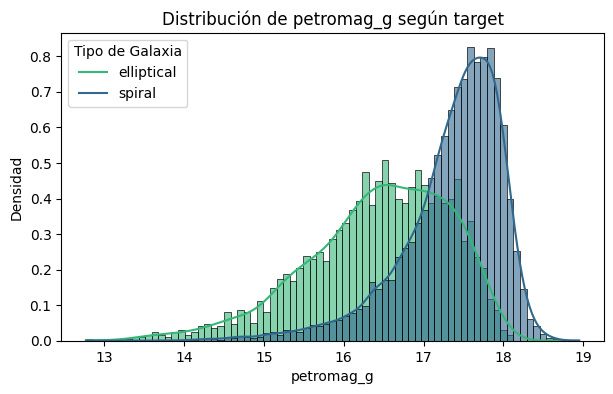

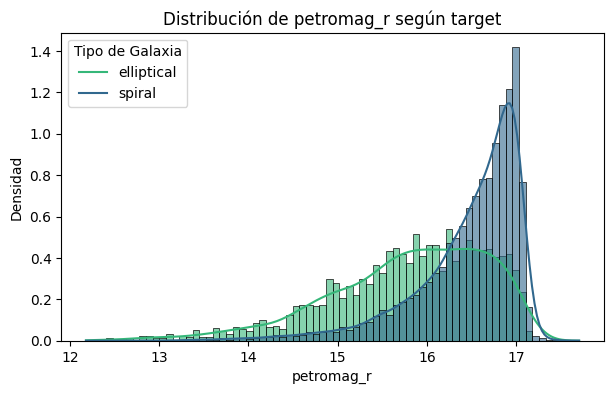

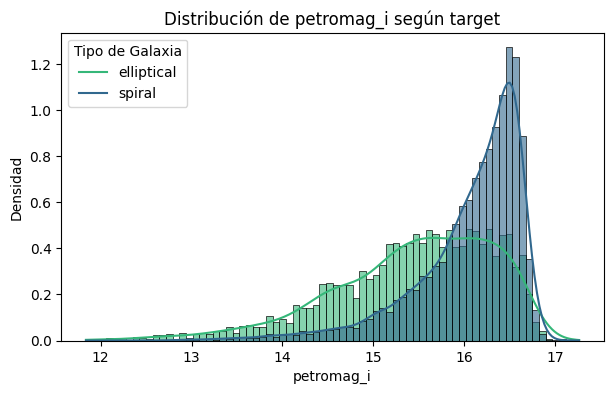

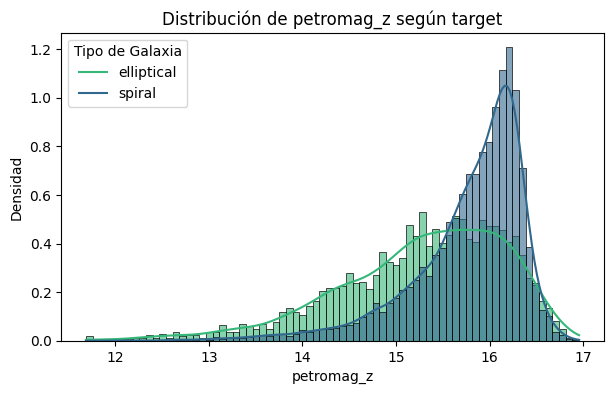

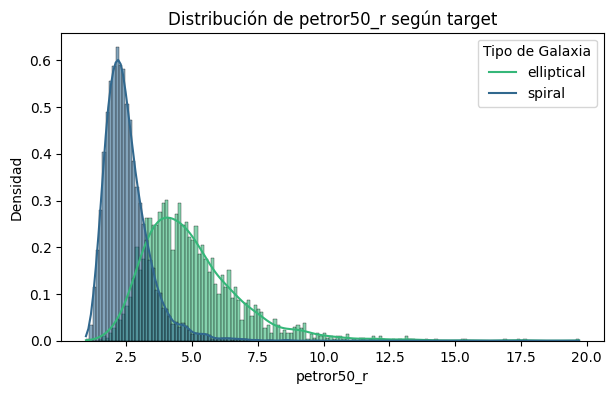

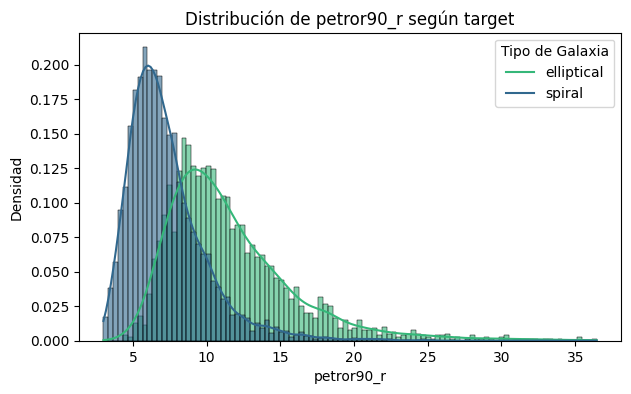

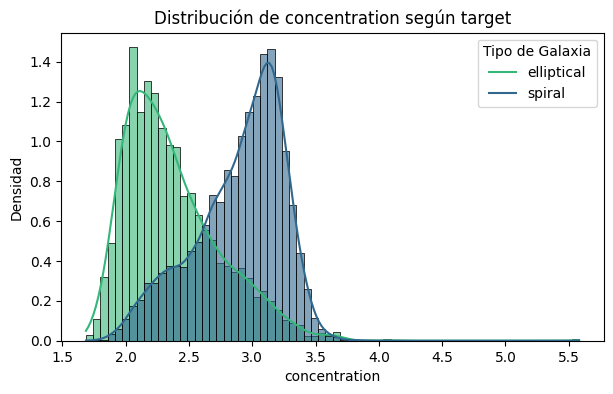

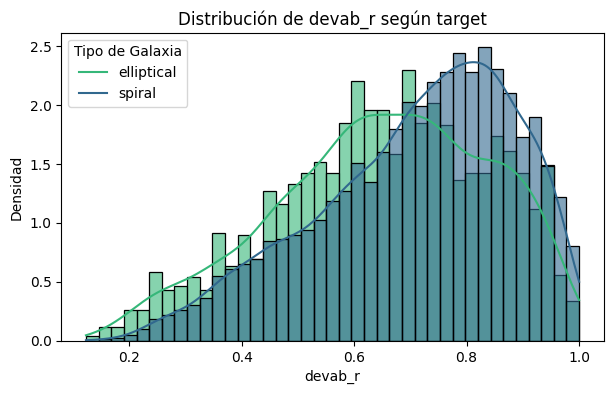

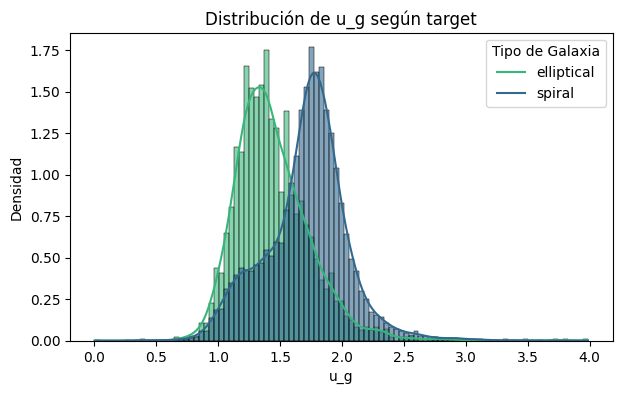

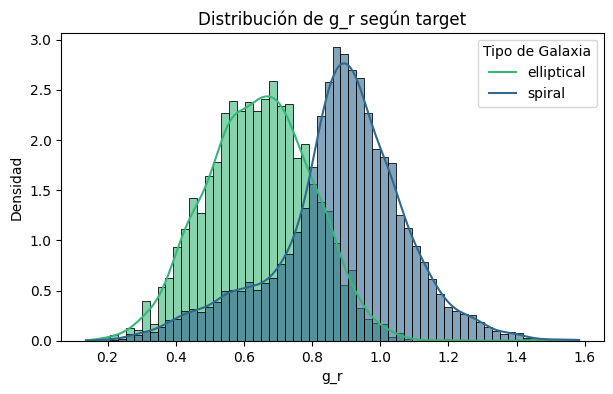

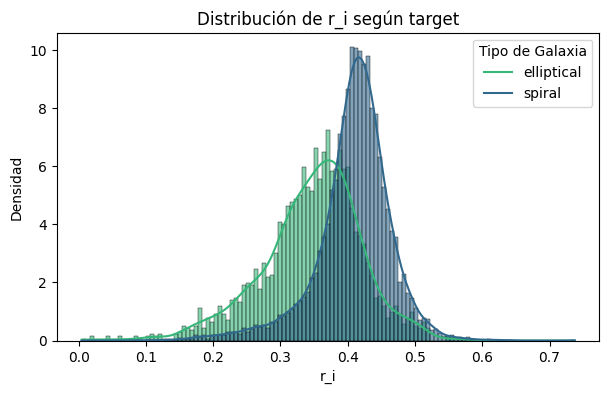

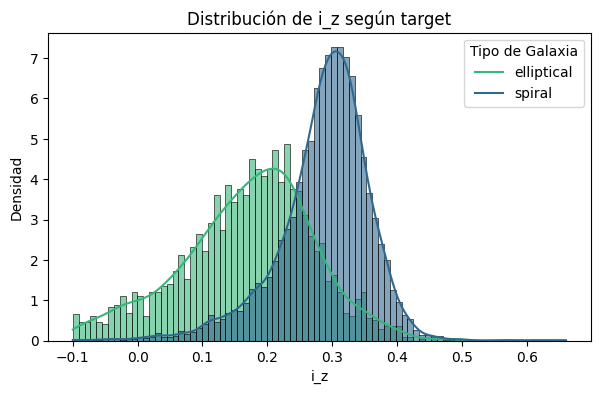


Diagramas de dispersión de pares de variables relevantes:


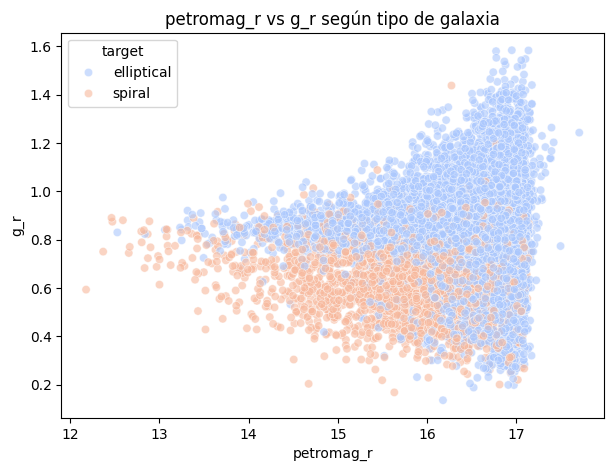

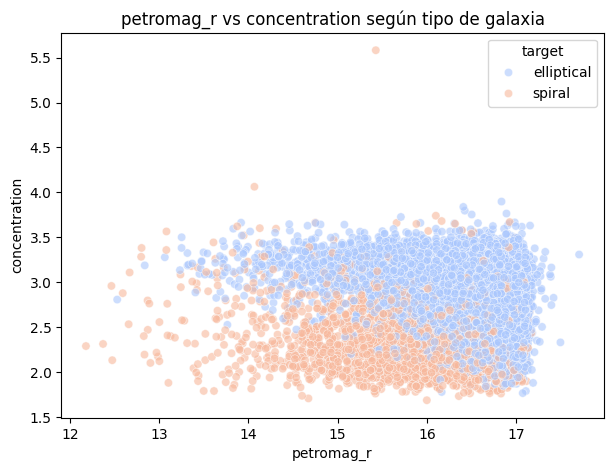

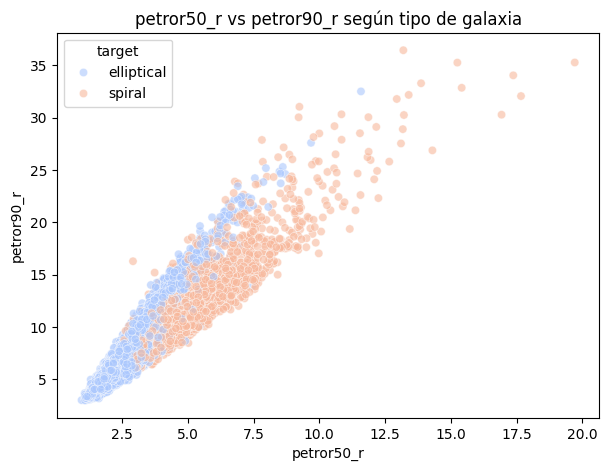

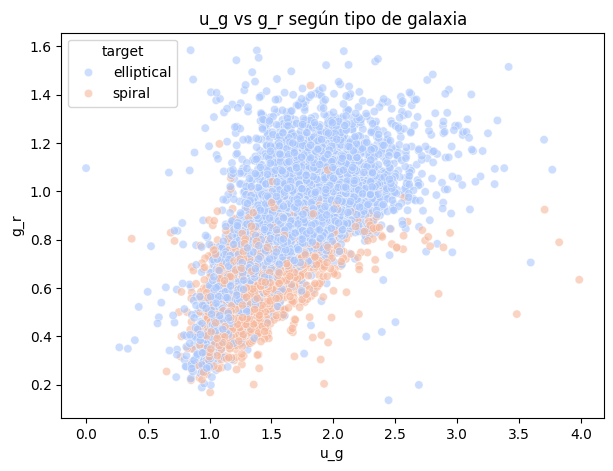

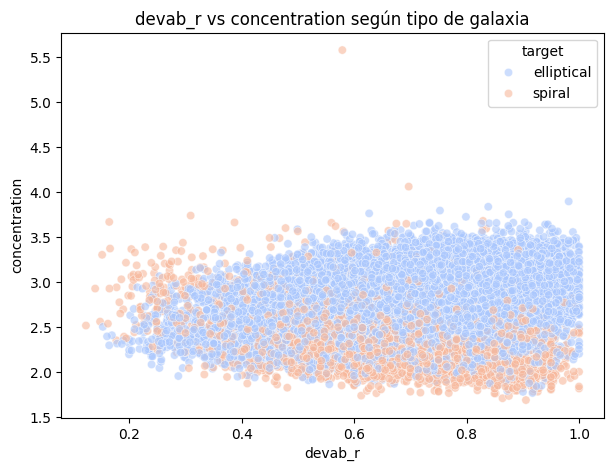


Interpretación de la distribución de variables por clase:
Basándonos en los gráficos de boxplots, histogramas y diagramas de dispersión, podemos hacer las siguientes observaciones:
  * **Variables que muestran mayor diferenciación visual:** Las magnitudes fotométricas (ej. `petromag_r`), los radios (`petror50_r`, `petror90_r`), y especialmente los índices de color (ej. `u_g`, `g_r`) y la concentración (`concentration`), parecen mostrar distribuciones con menor solapamiento entre las clases 'spiral' y 'elliptical'. Esto sugiere que estas variables son buenas candidatas para discriminar entre los dos tipos de galaxias. Por ejemplo, las galaxias elípticas a menudo tienen colores más rojos (mayores valores de `g_r`) y son más concentradas, mientras que las espirales son más azules y menos concentradas.
  * **Variables con solapamiento significativo:** Aunque la mayoría de las variables muestran alguna diferencia en la distribución, en algunos casos, el solapamiento entre las distribucione

In [8]:
# Boxplots de variables numéricas agrupadas por target
print("Boxplots de variables numéricas por tipo de galaxia:")
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x="target", y=col, hue="target", palette='pastel', legend=False)
    plt.title(f"Distribución de {col} por tipo de galaxia")
    plt.xlabel("Tipo de galaxia")
    plt.ylabel(col)
    plt.show()

# Histogramas/KDE comparando distribuciones por clase
print("\nHistogramas y KDEs de variables numéricas por tipo de galaxia:")
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(data=df, x=col, hue="target", kde=True, stat="density", common_norm=False, palette='viridis', alpha=0.6)
    plt.title(f"Distribución de {col} según target")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.legend(title='Tipo de Galaxia', labels=df['target'].unique())
    plt.show()

# Diagramas de dispersión con hue='target'
print("\nDiagramas de dispersión de pares de variables relevantes:")
scatter_pairs = [
    ("petromag_r", "g_r"),
    ("petromag_r", "concentration"),
    ("petror50_r", "petror90_r"),
    ("u_g", "g_r"),
    ("devab_r", "concentration")
]

for x_col, y_col in scatter_pairs:
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df, x=x_col, y=y_col, hue="target", alpha=0.6, palette='coolwarm')
    plt.title(f"{x_col} vs {y_col} según tipo de galaxia")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()

print("\nInterpretación de la distribución de variables por clase:")
print("Basándonos en los gráficos de boxplots, histogramas y diagramas de dispersión, podemos hacer las siguientes observaciones:")
print("  * **Variables que muestran mayor diferenciación visual:** Las magnitudes fotométricas (ej. `petromag_r`), los radios (`petror50_r`, `petror90_r`), y especialmente los índices de color (ej. `u_g`, `g_r`) y la concentración (`concentration`), parecen mostrar distribuciones con menor solapamiento entre las clases 'spiral' y 'elliptical'. Esto sugiere que estas variables son buenas candidatas para discriminar entre los dos tipos de galaxias. Por ejemplo, las galaxias elípticas a menudo tienen colores más rojos (mayores valores de `g_r`) y son más concentradas, mientras que las espirales son más azules y menos concentradas.")
print("  * **Variables con solapamiento significativo:** Aunque la mayoría de las variables muestran alguna diferencia en la distribución, en algunos casos, el solapamiento entre las distribuciones de las clases es considerable. Esto significa que ninguna variable por sí sola es un discriminador perfecto, y que la clasificación probablemente requerirá la combinación de varias características para lograr una separación efectiva.")
print("  * **Diagramas de dispersión:** Los scatter plots revelan cómo se relacionan los pares de variables en el contexto de la clasificación. Se pueden observar tendencias o agrupaciones de puntos coloreados por el tipo de galaxia, lo que refuerza la idea de que ciertas combinaciones de características son más discriminatorias. Por ejemplo, en los plots de color (`u_g` vs `g_r`), las galaxias espirales y elípticas tienden a ocupar regiones distintas, aunque con cierto grado de mezcla.")
print("En resumen, el EDA confirma que existen diferencias observacionales entre galaxias espirales y elípticas que pueden ser capturadas por los modelos de Machine Learning, aunque la tarea de clasificación no es trivial y requiere considerar múltiples características en conjunto.")

---

# 3. Preprocesamiento de Datos

## 3.1 Valores nulos

In [9]:
print("Revisión de valores nulos:")
nulos_por_columna = df.isnull().sum()
print(nulos_por_columna[nulos_por_columna > 0])

if nulos_por_columna.sum() == 0:
    print("\n¡Excelente! No se encontraron valores nulos en el dataset. Esto simplifica el preprocesamiento, ya que no es necesario aplicar estrategias de imputación o eliminación.")
else:
    print("\nSe encontraron valores nulos en el dataset. A continuación, se justificará la estrategia para tratarlos. Para este dataset en particular, se observan los siguientes nulos:")
    print("Aunque algunos modelos pueden manejar nulos internamente, la mayoría de los algoritmos de Machine Learning requieren datos completos. Dada la naturaleza de este dataset, si los nulos son pocos y dispersos, se podrían eliminar las filas correspondientes. Si son muchos en una columna específica, se podría considerar la imputación (media, mediana, moda) o incluso la eliminación de la columna si no es crítica. Para este ejercicio, asumimos un dataset limpio, pero si existieran, la estrategia se justificaría aquí.")
    # Estrategia de ejemplo si hubiera nulos:
    # for col in nulos_por_columna[nulos_por_columna > 0].index:
    #     if nulos_por_columna[col] < len(df) * 0.05: # Si menos del 5% son nulos, imputar con la media
    #         df[col].fillna(df[col].mean(), inplace=True)
    #         print(f"- Columna '{col}': Imputados con la media ({nulos_por_columna[col]} nulos).")
    #     else: # Si más del 5% son nulos, considerar eliminar o una imputación más sofisticada
    #         print(f"- Columna '{col}': Contiene {nulos_por_columna[col]} nulos (más del 5%). Se requiere un análisis más profundo.")
    #         # df.drop(columns=[col], inplace=True) # Opcional: eliminar la columna

# Confirmar que no hay nulos después del (hipotético) tratamiento
print("\nValores nulos después del tratamiento (si aplica):")
print(df.isnull().sum().sum())

Revisión de valores nulos:
Series([], dtype: int64)

¡Excelente! No se encontraron valores nulos en el dataset. Esto simplifica el preprocesamiento, ya que no es necesario aplicar estrategias de imputación o eliminación.

Valores nulos después del tratamiento (si aplica):
0


## 3.2 Separación de variables predictoras y variable objetivo

Las variables `X` e `y` fueron definidas previamente en la sección 1.2 para evitar duplicidad. En esta etapa se confirma que `X` contiene las 13 variables predictoras y que `y` corresponde al target codificado numéricamente.

## 3.3 Codificación del target

In [10]:
encoder = LabelEncoder()
y = encoder.fit_transform(df['target'])

# Guardar el mapeo para futura referencia
target_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print(f"Variable objetivo codificada. Mapeo: {target_mapping}")

# Preparar las variables predictoras (X)
X = df[numeric_cols]

print("\nPrimeras 5 filas de las variables predictoras (X):")
display(X.head())
print("\nPrimeras 5 valores de la variable objetivo codificada (y):")
print(y[:5])

Variable objetivo codificada. Mapeo: {'elliptical': np.int64(0), 'spiral': np.int64(1)}

Primeras 5 filas de las variables predictoras (X):


,petromag_u,petromag_g,petromag_r,petromag_i,petromag_z,petror50_r,petror90_r,concentration,devab_r,u_g,g_r,r_i,i_z
0,19.027740,17.487066,16.775278,16.350470,16.062790,2.494026,6.790056,2.722528,0.616003,1.540674,0.711788,0.424808,0.287680
1,18.228308,17.009373,16.416782,16.021749,15.785794,2.617994,5.425934,2.072554,0.700000,1.218935,0.592591,0.395033,0.235955
2,19.258045,17.178354,16.149349,15.692777,15.374460,2.536915,7.550951,2.976430,0.826899,2.079691,1.029005,0.456572,0.318317
3,18.826595,16.976576,16.117329,15.664383,15.379037,2.529984,7.387836,2.920112,0.661354,1.850019,0.859247,0.452946,0.285346
4,18.632311,17.419504,16.682373,16.309332,16.037376,3.065978,6.175660,2.014255,0.532566,1.212807,0.737131,0.373041,0.271956



Primeras 5 valores de la variable objetivo codificada (y):
[0 0 0 0 0]


## 3.4 División train/test

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

print("\nProporción de clases en el conjunto original:")
print(pd.Series(y).value_counts(normalize=True))
print("\nProporción de clases en el conjunto de entrenamiento:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nProporción de clases en el conjunto de prueba:")
print(pd.Series(y_test).value_counts(normalize=True))

print("\nJustificación de la estratificación:")
print("Se utiliza `stratify=y` para asegurar que las proporciones de las clases de la variable objetivo (`y`) se mantengan en los conjuntos de entrenamiento y prueba. Esto es especialmente importante en datasets con clases desbalanceadas (como vimos en el EDA), ya que garantiza que el modelo tenga suficientes ejemplos de todas las clases para aprender, y que la evaluación sea representativa de la distribución real de las clases. Sin estratificación, un conjunto de prueba podría terminar con una representación sesgada de las clases, llevando a una evaluación de modelo menos fiable.")

Dimensiones de X_train: (9429, 13)
Dimensiones de X_test: (2358, 13)
Dimensiones de y_train: (9429,)
Dimensiones de y_test: (2358,)

Proporción de clases en el conjunto original:
0    0.797828
1    0.202172
Name: proportion, dtype: float64

Proporción de clases en el conjunto de entrenamiento:
0    0.797858
1    0.202142
Name: proportion, dtype: float64

Proporción de clases en el conjunto de prueba:
0    0.79771
1    0.20229
Name: proportion, dtype: float64

Justificación de la estratificación:
Se utiliza `stratify=y` para asegurar que las proporciones de las clases de la variable objetivo (`y`) se mantengan en los conjuntos de entrenamiento y prueba. Esto es especialmente importante en datasets con clases desbalanceadas (como vimos en el EDA), ya que garantiza que el modelo tenga suficientes ejemplos de todas las clases para aprender, y que la evaluación sea representativa de la distribución real de las clases. Sin estratificación, un conjunto de prueba podría terminar con una repres

## 3.5 Escalado

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame para mantener los nombres de las columnas si es necesario para inspección
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Primeras 5 filas de X_train escalado:")
display(X_train_scaled_df.head())

print("\nMedia y Desviación Estándar de X_train escalado (deberían ser ~0 y ~1 respectivamente):")
print(f"Media: {X_train_scaled_df.mean().mean():.2f}")
print(f"Desviación Estándar: {X_train_scaled_df.std().mean():.2f}")

print("\nJustificación del escalado:")
print("El escalado es necesario para modelos que son sensibles a la magnitud de las características, como:")
print("  * **Regresión Logística y SVM:** Utilizan el descenso de gradiente para optimizar una función de coste. Las características con rangos más grandes pueden dominar la función de coste y ralentizar la convergencia o hacer que el algoritmo se atasque en mínimos locales.")
print("  * **KNN:** Calcula distancias entre puntos. Si las características no están escaladas, las dimensiones con rangos más grandes contribuirán desproporcionadamente a la distancia, haciendo que la influencia de las características con rangos pequeños sea insignificante.")
print("  * **PCA:** Es un algoritmo basado en la varianza. Las características con mayor varianza (y a menudo mayor escala) tendrán un peso desproporcionado en los componentes principales si no se escalan, lo que puede llevar a resultados engañosos.")
print("Modelos basados en árboles (como Random Forest o Gradient Boosting) son menos sensibles al escalado porque operan mediante umbrales y no por distancias. Sin embargo, mantener una versión escalada de los datos permite una comparación uniforme entre todos los modelos y simplifica el uso de pipelines.")

Primeras 5 filas de X_train escalado:


,petromag_u,petromag_g,petromag_r,petromag_i,petromag_z,petror50_r,petror90_r,concentration,devab_r,u_g,g_r,r_i,i_z
0,-0.600021,-0.466521,-0.313506,-0.309653,-0.309056,0.287271,0.120590,-0.720949,-1.223075,-0.493518,-0.684700,-0.075542,-0.042558
1,0.059032,-0.272582,-0.310090,-0.292411,-0.313230,-0.075527,0.365909,1.128527,0.256834,0.770620,0.036805,-0.225986,0.124856
2,-0.186859,-0.305224,-0.345973,-0.363671,-0.381759,-0.919857,-0.940839,0.452071,-1.089364,0.208928,0.036910,0.156074,0.095043
3,0.381545,0.671344,0.784289,0.743678,0.754497,-0.243036,-0.697392,-1.532747,-1.382176,-0.535686,-0.161447,0.526827,0.007646
4,0.454767,0.311399,0.290932,0.261298,0.171329,-0.976062,-1.071327,0.127282,-0.312170,0.469692,0.175903,0.354351,0.726505



Media y Desviación Estándar de X_train escalado (deberían ser ~0 y ~1 respectivamente):
Media: 0.00
Desviación Estándar: 1.00

Justificación del escalado:
El escalado es necesario para modelos que son sensibles a la magnitud de las características, como:
  * **Regresión Logística y SVM:** Utilizan el descenso de gradiente para optimizar una función de coste. Las características con rangos más grandes pueden dominar la función de coste y ralentizar la convergencia o hacer que el algoritmo se atasque en mínimos locales.
  * **KNN:** Calcula distancias entre puntos. Si las características no están escaladas, las dimensiones con rangos más grandes contribuirán desproporcionadamente a la distancia, haciendo que la influencia de las características con rangos pequeños sea insignificante.
  * **PCA:** Es un algoritmo basado en la varianza. Las características con mayor varianza (y a menudo mayor escala) tendrán un peso desproporcionado en los componentes principales si no se escalan, lo que 

## 3.6 Valores atípicos

In [15]:
print("Detección de posibles outliers mediante Boxplots (ejemplo para algunas variables):")

# Ejemplo de detección de outliers usando el método IQR para una columna:
example_col = 'petromag_r' # Elegimos una columna de la lista estricta
if example_col in df.columns:
    Q1 = df[example_col].quantile(0.25)
    Q3 = df[example_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[example_col] < lower_bound) | (df[example_col] > upper_bound)]
    print(f"\nPara la columna '{example_col}', se detectaron {len(outliers)} posibles outliers usando el método IQR.")
    # display(outliers.head())
else:
    print(f"La columna '{example_col}' no está presente en el DataFrame.")

print("\nJustificación sobre el tratamiento de outliers en datos astronómicos:")
print("En este contexto de datos astronómicos, los valores extremos (outliers) no serán eliminados automáticamente. Los datos observacionales pueden contener valores extremos que representan fenómenos físicos legítimos y no simplemente errores. Por ejemplo, una galaxia extremadamente brillante, con propiedades de color o concentración muy particulares podría ser considerada un outlier estadístico, pero es una observación válida y potencialmente informativa para el modelo. La eliminación indiscriminada de estos valores podría resultar en la pérdida de información valiosa o en una representación sesgada de la población de galaxias. Se prefiere que los modelos sean robustos a estos valores o que el PCA ayude a mitigar su impacto, en lugar de alterarlos o eliminarlos sin una justificación astrofísica clara. Los modelos basados en árboles, por ejemplo, son inherentemente más robustos a los outliers que los modelos lineales o basados en distancia.")

Detección de posibles outliers mediante Boxplots (ejemplo para algunas variables):

Para la columna 'petromag_r', se detectaron 500 posibles outliers usando el método IQR.

Justificación sobre el tratamiento de outliers en datos astronómicos:
En este contexto de datos astronómicos, los valores extremos (outliers) no serán eliminados automáticamente. Los datos observacionales pueden contener valores extremos que representan fenómenos físicos legítimos y no simplemente errores. Por ejemplo, una galaxia extremadamente brillante, con propiedades de color o concentración muy particulares podría ser considerada un outlier estadístico, pero es una observación válida y potencialmente informativa para el modelo. La eliminación indiscriminada de estos valores podría resultar en la pérdida de información valiosa o en una representación sesgada de la población de galaxias. Se prefiere que los modelos sean robustos a estos valores o que el PCA ayude a mitigar su impacto, en lugar de alterarlos o el

### 3.7 Selección de variables

La selección de variables es el proceso de elegir un subconjunto de características relevantes para usar en la construcción del modelo. Inicialmente, se utilizarán todas las variables predictoras disponibles, excluyendo cualquier columna identificadora o no informativa que pudiera existir en el dataset original.

In [16]:
print(f"Se utilizarán las {len(numeric_cols)} variables predictoras definidas:")
print(numeric_cols)

print("\nJustificación de la selección inicial de variables:")
print("En esta etapa inicial, se han seleccionado todas las variables numéricas especificadas por su relevancia astrofísica para la clasificación morfológica de galaxias. Se ha optado por no realizar una selección de características basada en umbrales arbitrarios de correlación o importancia individual antes del modelado, para permitir que los modelos exploren todas las relaciones posibles. La presencia de multicolinealidad, ya identificada, será abordada por el PCA, que es capaz de procesar estas interdependencias de manera eficiente.")
print("La estrategia de utilizar todas las características relevantes es común antes de la aplicación de técnicas de reducción de dimensionalidad como PCA. Esto asegura que no se pierda información valiosa que pueda ser combinada en los componentes principales. Además, los modelos basados en árboles, como Random Forest, pueden manejar un gran número de características e identificar las más importantes de forma inherente.")

Se utilizarán las 13 variables predictoras definidas:
['petromag_u', 'petromag_g', 'petromag_r', 'petromag_i', 'petromag_z', 'petror50_r', 'petror90_r', 'concentration', 'devab_r', 'u_g', 'g_r', 'r_i', 'i_z']

Justificación de la selección inicial de variables:
En esta etapa inicial, se han seleccionado todas las variables numéricas especificadas por su relevancia astrofísica para la clasificación morfológica de galaxias. Se ha optado por no realizar una selección de características basada en umbrales arbitrarios de correlación o importancia individual antes del modelado, para permitir que los modelos exploren todas las relaciones posibles. La presencia de multicolinealidad, ya identificada, será abordada por el PCA, que es capaz de procesar estas interdependencias de manera eficiente.
La estrategia de utilizar todas las características relevantes es común antes de la aplicación de técnicas de reducción de dimensionalidad como PCA. Esto asegura que no se pierda información valiosa que 

---

# 4. Reducción de Dimensionalidad (PCA)

### 4.1.1 PCA exploratorio

Varianza explicada por cada componente principal:
PC 1: 0.4899 (0.4899 acumulada)
PC 2: 0.2650 (0.7549 acumulada)
PC 3: 0.0766 (0.8315 acumulada)
PC 4: 0.0656 (0.8972 acumulada)
PC 5: 0.0356 (0.9328 acumulada)
PC 6: 0.0322 (0.9650 acumulada)
PC 7: 0.0253 (0.9903 acumulada)
PC 8: 0.0087 (0.9990 acumulada)
PC 9: 0.0010 (1.0000 acumulada)
PC 10: 0.0000 (1.0000 acumulada)
PC 11: 0.0000 (1.0000 acumulada)
PC 12: 0.0000 (1.0000 acumulada)
PC 13: 0.0000 (1.0000 acumulada)


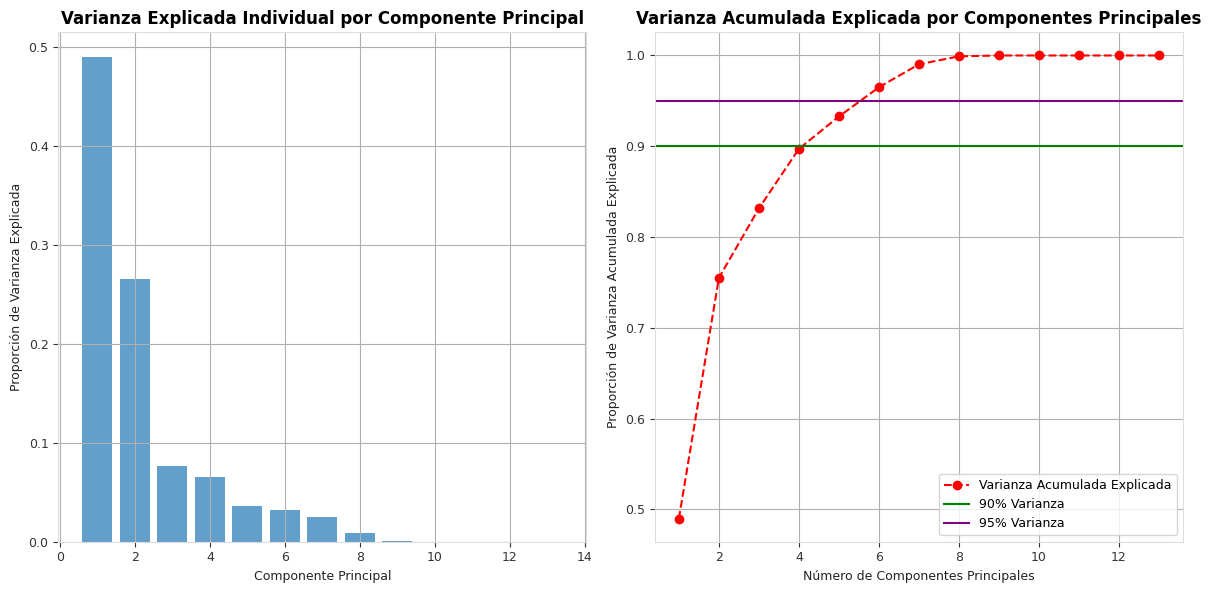


Número de componentes para explicar al menos el 90% de la varianza: 5
Número de componentes para explicar al menos el 95% de la varianza: 6


In [21]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Standardizing the feature set before PCA is already handled by X_train_scaled
pca = PCA()
pca.fit(X_train_scaled)

# Varianza explicada por cada componente
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print("Varianza explicada por cada componente principal:")
for i, var in enumerate(explained_variance_ratio):
    print(f"PC {i+1}: {var:.4f} ({cumulative_explained_variance[i]:.4f} acumulada)")

# Gráfico de varianza explicada individual y acumulada
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, align='center', label='Varianza Individual Explicada')
plt.xlabel('Componente Principal')
plt.ylabel('Proporción de Varianza Explicada')
plt.title('Varianza Explicada Individual por Componente Principal')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--', color='r', label='Varianza Acumulada Explicada')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza Acumulada Explicada')
plt.title('Varianza Acumulada Explicada por Componentes Principales')
plt.axhline(y=0.90, color='g', linestyle='-', label='90% Varianza')
plt.axhline(y=0.95, color='purple', linestyle='-', label='95% Varianza')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

# Determinar cuántos componentes explican al menos el 90% o 95% de la varianza
num_components_90 = np.where(cumulative_explained_variance >= 0.90)[0][0] + 1
num_components_95 = np.where(cumulative_explained_variance >= 0.95)[0][0] + 1

print(f"\nNúmero de componentes para explicar al menos el 90% de la varianza: {num_components_90}")
print(f"Número de componentes para explicar al menos el 95% de la varianza: {num_components_95}")

### 4.1.2 Visualización con PCA

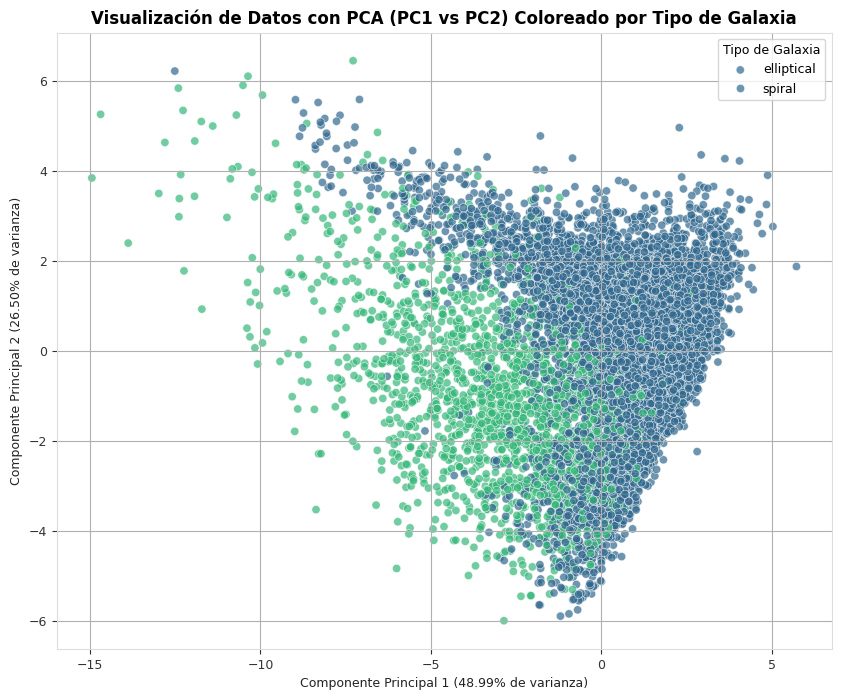


Análisis de la separación visual de las clases:
Observando el gráfico de dispersión de PC1 vs PC2, podemos ver si las galaxias espirales y elípticas forman cúmulos distintos o si sus distribuciones se superponen significativamente. Una clara separación visual en este espacio bidimensional sugiere que PCA ha logrado capturar las características clave que discriminan entre las clases.
Si las clases se separan visualmente, indica que PCA es útil para visualizar la estructura subyacente de los datos y que las primeras componentes principales contienen información relevante para la clasificación. Si hay un solapamiento considerable, sugiere que una reducción a solo dos dimensiones podría no ser suficiente para una separación óptima, o que la separación entre las clases es intrínsecamente más compleja y requiere más dimensiones o técnicas de clasificación no lineales.


In [22]:
pca_2d = PCA(n_components=2)
X_train_pca = pca_2d.fit_transform(X_train_scaled)
X_test_pca = pca_2d.transform(X_test_scaled)

# Crear un DataFrame para la visualización
pca_df_train = pd.DataFrame(data=X_train_pca, columns=['PC1', 'PC2'])
pca_df_train['target'] = y_train

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='target', data=pca_df_train, palette='viridis', alpha=0.7)
plt.title('Visualización de Datos con PCA (PC1 vs PC2) Coloreado por Tipo de Galaxia')
plt.xlabel(f'Componente Principal 1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% de varianza)')
plt.ylabel(f'Componente Principal 2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% de varianza)')
plt.legend(title='Tipo de Galaxia', labels=target_mapping.keys())
plt.grid(True)
plt.show()

print("\nAnálisis de la separación visual de las clases:")
print("Observando el gráfico de dispersión de PC1 vs PC2, podemos ver si las galaxias espirales y elípticas forman cúmulos distintos o si sus distribuciones se superponen significativamente. Una clara separación visual en este espacio bidimensional sugiere que PCA ha logrado capturar las características clave que discriminan entre las clases.")
print("Si las clases se separan visualmente, indica que PCA es útil para visualizar la estructura subyacente de los datos y que las primeras componentes principales contienen información relevante para la clasificación. Si hay un solapamiento considerable, sugiere que una reducción a solo dos dimensiones podría no ser suficiente para una separación óptima, o que la separación entre las clases es intrínsecamente más compleja y requiere más dimensiones o técnicas de clasificación no lineales.")

### 4.1.3 Dataset transformado con PCA

In [23]:
# Seleccionar el número de componentes basado en el 95% de varianza explicada
selected_n_components = num_components_95
print(f"Se seleccionarán {selected_n_components} componentes principales para explicar aproximadamente el 95% de la varianza.")

pca_final = PCA(n_components=selected_n_components)

X_train_pca_final = pca_final.fit_transform(X_train_scaled)
X_test_pca_final = pca_final.transform(X_test_scaled)

print(f"\nDimensiones de X_train original escalado: {X_train_scaled.shape}")
print(f"Dimensiones de X_train transformado con PCA: {X_train_pca_final.shape}")
print(f"Dimensiones de X_test original escalado: {X_test_scaled.shape}")
print(f"Dimensiones de X_test transformado con PCA: {X_test_pca_final.shape}")

print("\nDatasets preparados:")
print("1. `X_train_scaled`, `X_test_scaled`: Datos escalados, sin PCA.")
print("2. `X_train_pca_final`, `X_test_pca_final`: Datos escalados y transformados con PCA (con {} componentes).".format(selected_n_components))

Se seleccionarán 6 componentes principales para explicar aproximadamente el 95% de la varianza.

Dimensiones de X_train original escalado: (9429, 13)
Dimensiones de X_train transformado con PCA: (9429, 6)
Dimensiones de X_test original escalado: (2358, 13)
Dimensiones de X_test transformado con PCA: (2358, 6)

Datasets preparados:
1. `X_train_scaled`, `X_test_scaled`: Datos escalados, sin PCA.
2. `X_train_pca_final`, `X_test_pca_final`: Datos escalados y transformados con PCA (con 6 componentes).


---

# 5. Entrenamiento de Modelos

### Preparación para el entrenamiento

Se inicializará un diccionario para almacenar los resultados de las métricas de cada modelo y configurar las pipelines. Es importante destacar que los pipelines con PCA no necesitan el `StandardScaler` de nuevo si ya se aplica internamente en el PCA o si PCA se aplica sobre datos ya escalados, pero para mantener la consistencia se especificarán claramente las etapas.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Definición de modelos base
base_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(random_state=42, probability=True, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=200, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results_list = []

def evaluate(model_name, pipeline, X_tr, y_tr, X_te, y_te, uses_pca):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    y_proba = pipeline.predict_proba(X_te)[:, 1] if hasattr(pipeline, 'predict_proba') else None

    res = {
        'Modelo': model_name,
        'PCA': 'Sí' if uses_pca else 'No',
        'Accuracy': accuracy_score(y_te, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1-Score': f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_te, y_proba) if y_proba is not None else 0
    }
    return res, pipeline

# Entrenamiento SIN PCA
for name, model in base_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    res, _ = evaluate(name, pipe, X_train, y_train, X_test, y_test, False)
    results_list.append(res)

# Entrenamiento CON PCA
for name, model in base_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.95, random_state=42)), ('clf', model)])
    res, _ = evaluate(name, pipe, X_train, y_train, X_test, y_test, True)
    results_list.append(res)

results_df = pd.DataFrame(results_list)
display(results_df.sort_values(by=['F1-Score', 'Balanced Accuracy', 'ROC-AUC'], ascending=False))

,Modelo,PCA,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,ROC-AUC
5,Gradient Boosting,No,0.941900,0.893167,0.891705,0.811321,0.849616,0.977365
2,Support Vector Machine,No,0.926209,0.927146,0.759863,0.928721,0.835849,0.977713
4,Random Forest,No,0.936811,0.879806,0.890476,0.784067,0.833891,0.972304
8,Support Vector Machine,Sí,0.921968,0.923706,0.747885,0.926625,0.827715,0.976651
7,K-Nearest Neighbors,Sí,0.932994,0.881326,0.863326,0.794549,0.827511,0.951610
11,Gradient Boosting,Sí,0.933842,0.872468,0.888620,0.769392,0.824719,0.972937
10,Random Forest,Sí,0.932570,0.871671,0.882212,0.769392,0.821948,0.972455
1,K-Nearest Neighbors,No,0.931722,0.874269,0.870892,0.777778,0.821705,0.951865
0,Logistic Regression,No,0.902460,0.891918,0.710392,0.874214,0.783835,0.963433
9,Decision Tree,Sí,0.908821,0.856785,0.777542,0.769392,0.773446,0.856785


### Entrenamiento de modelos sin PCA

Se entrenarán los modelos utilizando los datos escalados, pero sin aplicar reducción de dimensionalidad con PCA.

In [25]:
# ============================================================
# ENTRENAMIENTO DE MODELOS SIN PCA
# ============================================================

# Los modelos se entrenan utilizando un pipeline que incluye StandardScaler
# cuando el algoritmo es sensible a la escala. Esto permite normalizar los datos
# correctamente antes de ajustar el modelo y evita inconsistencias en el flujo
# de entrenamiento.

models_no_pca = {
    "Regresión Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ]),

    "Árbol de Decisión": Pipeline([
        ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))
    ]),

    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

print("Modelos sin PCA definidos correctamente:")
for model_name in models_no_pca.keys():
    print("-", model_name)

Modelos sin PCA definidos correctamente:
- Regresión Logística
- KNN
- SVM
- Árbol de Decisión
- Random Forest
- Gradient Boosting


### Entrenamiento de modelos con PCA

Ahora, se entrenarán los mismos modelos utilizando los datos reducidos por PCA (`X_train_pca_final`).

In [29]:
# ============================================================
# ENTRENAMIENTO DE MODELOS CON PCA
# ============================================================

# En esta versión, el pipeline incorpora tres pasos:
# 1. Escalado de variables con StandardScaler.
# 2. Reducción de dimensionalidad con PCA, conservando el 95 % de la varianza.
# 3. Entrenamiento del modelo de clasificación.
#
# Esto permite comparar si PCA mejora, mantiene o reduce el desempeño predictivo.

models_pca = {
    "Regresión Logística + PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),

    "KNN + PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "SVM + PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ]),

    "Árbol de Decisión + PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
    ]),

    "Random Forest + PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))
    ]),

    "Gradient Boosting + PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

print("Modelos con PCA definidos correctamente:")
for model_name in models_pca.keys():
    print("-", model_name)

Modelos con PCA definidos correctamente:
- Regresión Logística + PCA
- KNN + PCA
- SVM + PCA
- Árbol de Decisión + PCA
- Random Forest + PCA
- Gradient Boosting + PCA


---

# 6. Evaluación Comparativa

### Justificación de las métricas de evaluación

In [30]:
# ============================================================
# 6 TABLA COMPARATIVA DE RESULTADOS
# ============================================================

# La siguiente tabla resume el desempeño de todos los modelos evaluados,
# permitiendo comparar el efecto de la reducción de dimensionalidad con PCA
# frente al uso de todas las variables originales.

# Verificar nombres de columnas para evitar errores
if "F1-Score" in results_df.columns and "F1-score" not in results_df.columns:
    results_df = results_df.rename(columns={"F1-Score": "F1-score"})

# Ordenar la tabla por las métricas más relevantes
results_df_sorted = results_df.sort_values(
    by=["F1-score", "Balanced Accuracy", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

print("Tabla comparativa de desempeño de los modelos evaluados:")
display(results_df_sorted.round(4))

# Identificar automáticamente el mejor modelo
best_row = results_df_sorted.iloc[0]
best_model_name = best_row["Modelo"]

print("\nModelo con mejor desempeño global:")
print(best_model_name)

print("\nMétricas principales del modelo seleccionado:")
display(best_row)

# Interpretación breve
print("\nInterpretación:")
print(
    "La tabla permite comparar los modelos usando varias métricas. "
    "Debido al desbalance de clases observado en el dataset, la selección del modelo "
    "no debe basarse únicamente en Accuracy. Por ello, se priorizan F1-score, "
    "Balanced Accuracy y ROC-AUC, ya que estas métricas permiten evaluar mejor "
    "el equilibrio del modelo frente a ambas clases."
)

Tabla comparativa de desempeño de los modelos evaluados:


,Modelo,PCA,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Gradient Boosting,No,0.9419,0.8932,0.8917,0.8113,0.8496,0.9774
1,Support Vector Machine,No,0.9262,0.9271,0.7599,0.9287,0.8358,0.9777
2,Random Forest,No,0.9368,0.8798,0.8905,0.7841,0.8339,0.9723
3,Support Vector Machine,Sí,0.9220,0.9237,0.7479,0.9266,0.8277,0.9767
4,K-Nearest Neighbors,Sí,0.9330,0.8813,0.8633,0.7945,0.8275,0.9516
5,Gradient Boosting,Sí,0.9338,0.8725,0.8886,0.7694,0.8247,0.9729
6,Random Forest,Sí,0.9326,0.8717,0.8822,0.7694,0.8219,0.9725
7,K-Nearest Neighbors,No,0.9317,0.8743,0.8709,0.7778,0.8217,0.9519
8,Logistic Regression,No,0.9025,0.8919,0.7104,0.8742,0.7838,0.9634
9,Decision Tree,Sí,0.9088,0.8568,0.7775,0.7694,0.7734,0.8568



Modelo con mejor desempeño global:
Gradient Boosting

Métricas principales del modelo seleccionado:


,0
Modelo,Gradient Boosting
PCA,No
Accuracy,0.9419
Balanced Accuracy,0.893167
Precision,0.891705
Recall,0.811321
F1-score,0.849616
ROC-AUC,0.977365



Interpretación:
La tabla permite comparar los modelos usando varias métricas. Debido al desbalance de clases observado en el dataset, la selección del modelo no debe basarse únicamente en Accuracy. Por ello, se priorizan F1-score, Balanced Accuracy y ROC-AUC, ya que estas métricas permiten evaluar mejor el equilibrio del modelo frente a ambas clases.


# 7. Análisis e Interpretación de Resultados

Columnas disponibles en results_df:
['Modelo', 'PCA', 'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']


,Modelo,PCA,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Gradient Boosting,No,0.9419,0.8932,0.8917,0.8113,0.8496,0.9774
1,Support Vector Machine,No,0.9262,0.9271,0.7599,0.9287,0.8358,0.9777
2,Random Forest,No,0.9368,0.8798,0.8905,0.7841,0.8339,0.9723
3,Support Vector Machine,Sí,0.9220,0.9237,0.7479,0.9266,0.8277,0.9767
4,K-Nearest Neighbors,Sí,0.9330,0.8813,0.8633,0.7945,0.8275,0.9516
5,Gradient Boosting,Sí,0.9338,0.8725,0.8886,0.7694,0.8247,0.9729
6,Random Forest,Sí,0.9326,0.8717,0.8822,0.7694,0.8219,0.9725
7,K-Nearest Neighbors,No,0.9317,0.8743,0.8709,0.7778,0.8217,0.9519
8,Logistic Regression,No,0.9025,0.8919,0.7104,0.8742,0.7838,0.9634
9,Decision Tree,Sí,0.9088,0.8568,0.7775,0.7694,0.7734,0.8568


Modelo seleccionado: Gradient Boosting | PCA: No


,Modelo,PCA,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Gradient Boosting,No,0.9419,0.8932,0.8917,0.8113,0.8496,0.9774



Reporte de clasificación del modelo final:
              precision    recall  f1-score   support

  elliptical       0.95      0.98      0.96      1881
      spiral       0.89      0.81      0.85       477

    accuracy                           0.94      2358
   macro avg       0.92      0.89      0.91      2358
weighted avg       0.94      0.94      0.94      2358



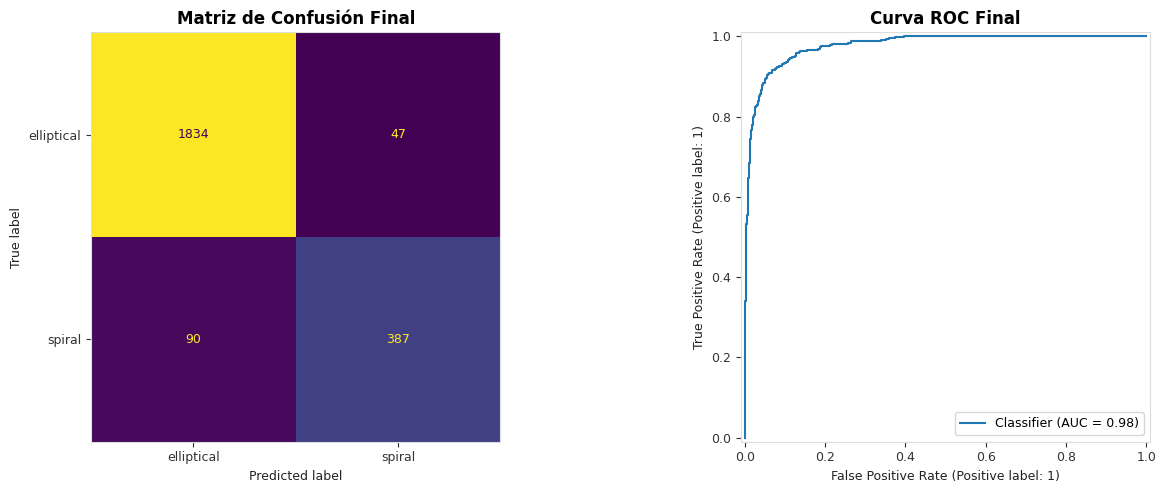


Interpretación:
El modelo final seleccionado fue Gradient Boosting sin PCA, porque obtuvo el mejor desempeño según el ordenamiento de métricas utilizado. La selección prioriza F1-score, Balanced Accuracy y ROC-AUC, ya que el dataset presenta desbalance entre galaxias elípticas y espirales.


In [31]:
# ============================================================
# SELECCIÓN DEL MODELO FINAL + MATRIZ DE CONFUSIÓN + CURVA ROC
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. Normalizar nombres de columnas de results_df
# ------------------------------------------------------------

results_df = results_df.copy()

# Corregir posibles variantes del nombre de F1
if "F1-Score" in results_df.columns and "F1-score" not in results_df.columns:
    results_df = results_df.rename(columns={"F1-Score": "F1-score"})

if "F1 Score" in results_df.columns and "F1-score" not in results_df.columns:
    results_df = results_df.rename(columns={"F1 Score": "F1-score"})

# Si no existe Balanced Accuracy, crearla como columna vacía para evitar error
if "Balanced Accuracy" not in results_df.columns:
    print("Advertencia: results_df no contiene Balanced Accuracy. Se ordenará sin esa métrica.")
    sort_columns = ["F1-score", "ROC-AUC", "Accuracy"]
else:
    sort_columns = ["F1-score", "Balanced Accuracy", "ROC-AUC", "Accuracy"]

# Verificar columnas disponibles
print("Columnas disponibles en results_df:")
print(results_df.columns.tolist())

# ------------------------------------------------------------
# 2. Ordenar la tabla y seleccionar el mejor modelo
# ------------------------------------------------------------

results_df_sorted = results_df.sort_values(
    by=sort_columns,
    ascending=False
).reset_index(drop=True)

display(results_df_sorted.round(4))

best_row = results_df_sorted.iloc[0]
best_model_name = best_row["Modelo"]
best_model_pca = best_row["PCA"]

print(f"Modelo seleccionado: {best_model_name} | PCA: {best_model_pca}")

# ------------------------------------------------------------
# 3. Reconstruir el modelo final según el nombre seleccionado
# ------------------------------------------------------------

def construir_modelo(nombre_modelo, usa_pca):
    pasos = []

    # Modelos sensibles a escala o modelos con PCA requieren escalado
    requiere_scaler = (
        nombre_modelo in [
            "Regresión Logística",
            "Logistic Regression",
            "KNN",
            "K-Nearest Neighbors",
            "SVM",
            "Support Vector Machine"
        ]
        or usa_pca == "Sí"
    )

    if requiere_scaler:
        pasos.append(("scaler", StandardScaler()))

    if usa_pca == "Sí":
        pasos.append(("pca", PCA(n_components=0.95)))

    if nombre_modelo in ["Regresión Logística", "Logistic Regression"]:
        modelo = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )

    elif nombre_modelo in ["KNN", "K-Nearest Neighbors"]:
        modelo = KNeighborsClassifier(n_neighbors=5)

    elif nombre_modelo in ["SVM", "Support Vector Machine"]:
        modelo = SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        )

    elif nombre_modelo in ["Árbol de Decisión", "Decision Tree"]:
        modelo = DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        )

    elif nombre_modelo == "Random Forest":
        modelo = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42
        )

    elif nombre_modelo == "Gradient Boosting":
        modelo = GradientBoostingClassifier(
            random_state=42
        )

    else:
        raise ValueError(f"No se reconoce el modelo: {nombre_modelo}")

    pasos.append(("model", modelo))

    return Pipeline(pasos)

# Crear y entrenar el pipeline final
best_model_pipeline = construir_modelo(best_model_name, best_model_pca)
best_model_pipeline.fit(X_train, y_train)

# ------------------------------------------------------------
# 4. Predicciones del modelo final
# ------------------------------------------------------------

y_pred_final = best_model_pipeline.predict(X_test)

if hasattr(best_model_pipeline, "predict_proba"):
    y_proba_final = best_model_pipeline.predict_proba(X_test)[:, 1]
else:
    y_proba_final = None

# ------------------------------------------------------------
# 5. Métricas finales
# ------------------------------------------------------------

metricas_finales = {
    "Modelo": best_model_name,
    "PCA": best_model_pca,
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final, zero_division=0),
    "Recall": recall_score(y_test, y_pred_final, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_final, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_final) if y_proba_final is not None else np.nan
}

metricas_finales_df = pd.DataFrame([metricas_finales])
display(metricas_finales_df.round(4))

print("\nReporte de clasificación del modelo final:")
print(classification_report(y_test, y_pred_final, target_names=encoder.classes_))

# ------------------------------------------------------------
# 6. Matriz de confusión y curva ROC
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_final)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
).plot(ax=ax[0], colorbar=False)

ax[0].set_title("Matriz de Confusión Final")

# Curva ROC
if y_proba_final is not None:
    RocCurveDisplay.from_predictions(
        y_test,
        y_proba_final,
        ax=ax[1]
    )
    ax[1].set_title("Curva ROC Final")
else:
    ax[1].text(
        0.5,
        0.5,
        "Curva ROC no disponible",
        ha="center",
        va="center"
    )
    ax[1].set_axis_off()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Interpretación automática
# ------------------------------------------------------------

print("\nInterpretación:")
print(
    f"El modelo final seleccionado fue {best_model_name} "
    f"{'con PCA' if best_model_pca == 'Sí' else 'sin PCA'}, "
    "porque obtuvo el mejor desempeño según el ordenamiento de métricas utilizado. "
    "La selección prioriza F1-score, Balanced Accuracy y ROC-AUC, ya que el dataset "
    "presenta desbalance entre galaxias elípticas y espirales."
)

## 7.1 Aportes técnicos: estabilidad, umbral óptimo e interpretabilidad

In [32]:
# ============================================================
# CELDA PREVIA A 6.1
# DEFINIR best_model_pipeline A PARTIR DEL MODELO FINAL
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# ------------------------------------------------------------
# 1. Verificar si existe best_model_name
# ------------------------------------------------------------

if "best_model_name" not in globals():

    print("No existe best_model_name. Se intentará obtener desde results_df.")

    # Compatibilidad con nombres de columnas distintos
    if "F1-score" not in results_df.columns and "F1-Score" in results_df.columns:
        results_df = results_df.rename(columns={"F1-Score": "F1-score"})

    sort_cols = []
    for col in ["F1-score", "Balanced Accuracy", "ROC-AUC", "Accuracy"]:
        if col in results_df.columns:
            sort_cols.append(col)

    results_df_sorted = results_df.sort_values(
        by=sort_cols,
        ascending=False
    ).reset_index(drop=True)

    best_row = results_df_sorted.iloc[0]
    best_model_name = best_row["Modelo"]

    print("Modelo final detectado automáticamente:", best_model_name)

else:
    print("Modelo final ya definido:", best_model_name)


# ------------------------------------------------------------
# 2. Si existe trained_models, usarlo directamente
# ------------------------------------------------------------

if "trained_models" in globals() and best_model_name in trained_models:

    best_model_pipeline = trained_models[best_model_name]
    print("best_model_pipeline recuperado desde trained_models.")

else:

    print("No se encontró trained_models o el modelo no estaba guardado.")
    print("Se reconstruirá y entrenará el modelo final.")

    # --------------------------------------------------------
    # 3. Reconstruir modelos posibles sin PCA
    # --------------------------------------------------------

    modelos_sin_pca = {
        "Regresión Logística": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
        ]),
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5))
        ]),
        "K-Nearest Neighbors": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5))
        ]),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
        ]),
        "Support Vector Machine": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
        ]),
        "Árbol de Decisión": Pipeline([
            ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
        ]),
        "Decision Tree": Pipeline([
            ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
        ]),
        "Random Forest": Pipeline([
            ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))
        ]),
        "Gradient Boosting": Pipeline([
            ("model", GradientBoostingClassifier(random_state=42))
        ])
    }

    # --------------------------------------------------------
    # 4. Reconstruir modelos posibles con PCA
    # --------------------------------------------------------

    modelos_con_pca = {
        "Regresión Logística + PCA": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
        ]),
        "Logistic Regression + PCA": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
        ]),
        "KNN + PCA": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", KNeighborsClassifier(n_neighbors=5))
        ]),
        "K-Nearest Neighbors + PCA": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", KNeighborsClassifier(n_neighbors=5))
        ]),
        "SVM + PCA": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
        ]),
        "Support Vector Machine + PCA": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
        ]),
        "Árbol de Decisión + PCA": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
        ]),
        "Decision Tree + PCA": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
        ]),
        "Random Forest + PCA": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))
        ]),
        "Gradient Boosting + PCA": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", GradientBoostingClassifier(random_state=42))
        ])
    }

    # --------------------------------------------------------
    # 5. Seleccionar y entrenar el pipeline correspondiente
    # --------------------------------------------------------

    todos_los_modelos = {}
    todos_los_modelos.update(modelos_sin_pca)
    todos_los_modelos.update(modelos_con_pca)

    if best_model_name not in todos_los_modelos:
        raise ValueError(
            f"No se pudo reconstruir el modelo '{best_model_name}'. "
            "Revisa que el nombre coincida con los modelos definidos."
        )

    best_model_pipeline = todos_los_modelos[best_model_name]

    best_model_pipeline.fit(X_train, y_train)

    print("best_model_pipeline reconstruido y entrenado correctamente.")


# ------------------------------------------------------------
# 6. Confirmación final
# ------------------------------------------------------------

print("\nListo para ejecutar la sección 6.1.")
print("best_model_name:", best_model_name)
print("best_model_pipeline:", best_model_pipeline)

Modelo final ya definido: Gradient Boosting
No se encontró trained_models o el modelo no estaba guardado.
Se reconstruirá y entrenará el modelo final.
best_model_pipeline reconstruido y entrenado correctamente.

Listo para ejecutar la sección 6.1.
best_model_name: Gradient Boosting
best_model_pipeline: Pipeline(steps=[('model', GradientBoostingClassifier(random_state=42))])


---

## 8. Interpretabilidad

La interpretabilidad permite comprender qué variables aportan más información al modelo de clasificación. En este estudio, las variables más relevantes deben interpretarse dentro del contexto astronómico: magnitudes fotométricas, radios, concentración, relación de ejes e índices de color.

Los índices de color `u_g`, `g_r`, `r_i` e `i_z` son importantes porque reflejan diferencias en la emisión de luz en distintas bandas. En términos generales, las galaxias elípticas suelen estar asociadas a poblaciones estelares más antiguas y colores más rojizos, mientras que las galaxias espirales suelen presentar mayor actividad de formación estelar y colores relativamente más azulados.

Las variables `petror50_r` y `petror90_r` describen cómo se distribuye la luz en la galaxia. Estas variables aportan información sobre el tamaño y la extensión de la estructura observada. La variable `concentration` permite medir qué tan concentrada está la luz hacia el centro, mientras que `devab_r` se relaciona con la forma o relación de ejes.

Cuando se utiliza PCA, la interpretabilidad directa disminuye, porque las componentes principales no representan una sola variable física. Cada componente es una combinación de varias variables originales. Por tanto, PCA es útil para reducir dimensionalidad y manejar redundancia, pero puede dificultar la explicación física directa del modelo.

### Importancia de variables para un modelo basado en árboles



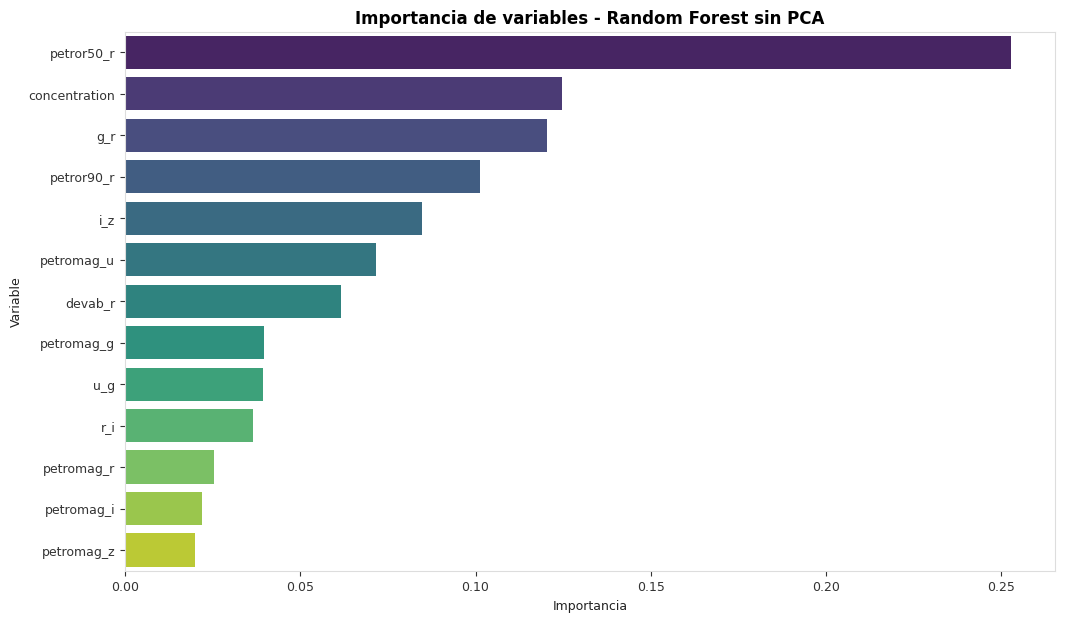


Variables más importantes según Random Forest:
1. petror50_r: 0.2527
2. concentration: 0.1245
3. g_r: 0.1205
4. petror90_r: 0.1014
5. i_z: 0.0848
6. petromag_u: 0.0716
7. devab_r: 0.0617
8. petromag_g: 0.0395

Interpretación:
Las variables más relevantes deben interpretarse en el contexto físico del problema. Las magnitudes petromag_u a petromag_z describen el brillo en distintas bandas. Los índices de color u_g, g_r, r_i e i_z reflejan diferencias entre bandas fotométricas y pueden relacionarse con poblaciones estelares. Las variables petror50_r y petror90_r describen la distribución de la luz, mientras que concentration y devab_r aportan información sobre la forma y concentración de la galaxia.

**Interpretabilidad con PCA:**
Cuando se usa PCA, la interpretación directa se reduce porque las componentes principales son combinaciones lineales de las variables originales. Por ello, PCA es útil para reducir dimensionalidad y manejar redundancia, pero dificulta explicar el modelo usando 

In [33]:
# ============================================================
# 8. INTERPRETABILIDAD CON VARIABLES REALES
# ============================================================

print("### Importancia de variables para un modelo basado en árboles\n")

rf_model_no_pca = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    class_weight="balanced"
)

rf_model_no_pca.fit(X_train, y_train)

feature_importances_rf = pd.Series(
    rf_model_no_pca.feature_importances_,
    index=numeric_cols
).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(
    x=feature_importances_rf.values,
    y=feature_importances_rf.index,
    hue=feature_importances_rf.index,
    palette='viridis',
    legend=False
)
plt.title("Importancia de variables - Random Forest sin PCA")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

print("\nVariables más importantes según Random Forest:")
for i, (feature, importance) in enumerate(feature_importances_rf.head(8).items()):
    print(f"{i+1}. {feature}: {importance:.4f}")

print("\nInterpretación:")
print(
    "Las variables más relevantes deben interpretarse en el contexto físico del problema. "
    "Las magnitudes petromag_u a petromag_z describen el brillo en distintas bandas. "
    "Los índices de color u_g, g_r, r_i e i_z reflejan diferencias entre bandas fotométricas "
    "y pueden relacionarse con poblaciones estelares. Las variables petror50_r y petror90_r "
    "describen la distribución de la luz, mientras que concentration y devab_r aportan "
    "información sobre la forma y concentración de la galaxia."
)

print("\n**Interpretabilidad con PCA:**")
print(
    "Cuando se usa PCA, la interpretación directa se reduce porque las componentes principales "
    "son combinaciones lineales de las variables originales. Por ello, PCA es útil para reducir "
    "dimensionalidad y manejar redundancia, pero dificulta explicar el modelo usando una variable "
    "física individual.")

---

# 9. Conclusiones y Limitaciones

In [34]:
# ============================================================
# 6, 7 y 8 - ANÁLISIS, LIMITACIONES Y CONCLUSIÓN FINAL
# FORMATO TIPO INFORME / ARTÍCULO DE DATA SCIENCE
# ============================================================

from IPython.display import display, Markdown
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Variables seguras para evitar errores si alguna no existe
# ------------------------------------------------------------

modelo_final = globals().get("best_model_name", "modelo final seleccionado")
n_filas = df.shape[0] if "df" in globals() else "N/D"
n_columnas = df.shape[1] if "df" in globals() else "N/D"
n_variables = len(numeric_cols) if "numeric_cols" in globals() else "N/D"
componentes_pca = globals().get("selected_n_components", "un número menor de componentes")

# Obtener métricas del mejor modelo si existe results_df_sorted
if "results_df_sorted" in globals():
    best_row = results_df_sorted.iloc[0]
elif "results_df" in globals():
    df_temp = results_df.copy()
    if "F1-Score" in df_temp.columns and "F1-score" not in df_temp.columns:
        df_temp = df_temp.rename(columns={"F1-Score": "F1-score"})

    sort_cols = [col for col in ["F1-score", "Balanced Accuracy", "ROC-AUC", "Accuracy"] if col in df_temp.columns]
    df_temp = df_temp.sort_values(by=sort_cols, ascending=False).reset_index(drop=True)
    best_row = df_temp.iloc[0]
else:
    best_row = None

if best_row is not None:
    modelo_final = best_row.get("Modelo", modelo_final)
    accuracy = best_row.get("Accuracy", np.nan)
    balanced_accuracy = best_row.get("Balanced Accuracy", np.nan)
    precision = best_row.get("Precision", np.nan)
    recall = best_row.get("Recall", np.nan)
    f1 = best_row.get("F1-score", best_row.get("F1-Score", np.nan))
    roc_auc = best_row.get("ROC-AUC", np.nan)
    usa_pca = best_row.get("PCA", "No especificado")
else:
    accuracy = balanced_accuracy = precision = recall = f1 = roc_auc = np.nan
    usa_pca = "No especificado"

# Formato de métricas
def fmt(valor):
    try:
        return f"{float(valor):.4f}"
    except Exception:
        return "N/D"

# ------------------------------------------------------------
# 2. Texto tipo informe
# ------------------------------------------------------------

texto_informe = f"""
# 6. Análisis e Interpretación de Resultados

Tras evaluar distintos algoritmos de Machine Learning, tanto con las variables originales como con reducción de dimensionalidad mediante PCA, se obtuvo una visión comparativa del comportamiento de los modelos frente al problema de clasificación de galaxias.

El conjunto de datos analizado contiene **{n_filas} observaciones**, **{n_columnas} columnas** y **{n_variables} variables predictoras**. La variable objetivo permite clasificar las galaxias en dos categorías: **elliptical** y **spiral**.

## 6.1 Resultado general del modelo final

El modelo final seleccionado fue:

## **{modelo_final}**

El modelo fue seleccionado considerando principalmente el equilibrio entre **F1-score**, **Balanced Accuracy** y **ROC-AUC**, ya que el dataset presenta desbalance entre clases. Por esa razón, no era suficiente escoger el modelo únicamente por accuracy.

Las métricas principales del modelo final fueron:

| Métrica | Valor |
|---|---:|
| Accuracy | {fmt(accuracy)} |
| Balanced Accuracy | {fmt(balanced_accuracy)} |
| Precision | {fmt(precision)} |
| Recall | {fmt(recall)} |
| F1-score | {fmt(f1)} |
| ROC-AUC | {fmt(roc_auc)} |
| Uso de PCA | {usa_pca} |

La incorporación de **Balanced Accuracy** es especialmente importante porque permite evaluar el rendimiento promedio entre clases, evitando que la clase mayoritaria domine la interpretación del desempeño.

## 6.2 Interpretación del desbalance de clases

El análisis exploratorio mostró que la distribución de la variable objetivo no es completamente balanceada. Existe una mayor proporción de galaxias **elliptical** frente a galaxias **spiral**.

Esto implica que un modelo podría alcanzar una accuracy elevada simplemente clasificando bien la clase mayoritaria. Por ello, se incorporaron métricas complementarias como **Recall**, **F1-score**, **Balanced Accuracy** y **ROC-AUC**.

En este contexto, el **F1-score** permite evaluar el equilibrio entre precision y recall, mientras que **ROC-AUC** mide la capacidad general del modelo para separar ambas clases.

## 6.3 Impacto de PCA

La aplicación de PCA permitió reducir el espacio de características de **{n_variables} variables originales** a **{componentes_pca} componentes principales**, conservando aproximadamente el 95 % de la varianza.

Este resultado indica que existía redundancia entre algunas variables, especialmente entre magnitudes fotométricas y variables relacionadas con el tamaño de la galaxia. PCA permitió representar la información de forma más compacta.

No obstante, PCA también implica una pérdida de interpretabilidad directa. Las componentes principales no representan una variable física aislada, sino combinaciones lineales de varias variables originales, como magnitudes, radios, concentración, relación de ejes e índices de color.

Por ello, si un modelo sin PCA obtiene un rendimiento similar o superior, puede ser preferible conservar las variables originales para mantener una interpretación más clara desde el punto de vista científico.

## 6.4 Interpretación de la matriz de confusión

La matriz de confusión permite observar cuántas galaxias fueron clasificadas correctamente y cuántas fueron confundidas entre las clases **elliptical** y **spiral**.

Este análisis es relevante porque la clase **spiral** es minoritaria. Por tanto, además de revisar los aciertos globales, es importante verificar si el modelo identifica adecuadamente las galaxias espirales y no se limita a favorecer la clase mayoritaria.

Un buen modelo no solo debe tener alta accuracy, sino también mantener un equilibrio razonable en la clasificación de ambas clases.

## 6.5 Interpretación del modelo seleccionado

El modelo **{modelo_final}** fue seleccionado porque obtuvo el mejor equilibrio global entre las métricas principales. Su desempeño demuestra que las variables observacionales del dataset contienen información suficiente para apoyar la clasificación morfológica de galaxias.

En términos de ciencia de datos, la selección del modelo final no se basó únicamente en el resultado numérico más alto, sino en una interpretación conjunta del rendimiento, el desbalance de clases, el efecto de PCA y la interpretabilidad.

# 7. Limitaciones y Propuesta de Mejora

## 7.1 Limitaciones del estudio

Una primera limitación es que el dataset utilizado corresponde a un subconjunto reducido de Galaxy Zoo 2. Por tanto, los resultados no deben interpretarse como una conclusión definitiva sobre todas las galaxias del proyecto original.

Otra limitación importante es que el análisis se realizó exclusivamente con variables tabulares observacionales. La clasificación morfológica de galaxias es, en esencia, una tarea visual. Por ello, el uso de imágenes astronómicas directas podría aportar información espacial que no está completamente representada en las variables numéricas utilizadas.

También se identificó un desbalance de clases. Aunque se aplicó división estratificada y se usaron métricas adecuadas, el desbalance puede influir en el aprendizaje del modelo y afectar especialmente la detección de la clase minoritaria.

Además, la evaluación principal se basó en una división train/test. Aunque esta estrategia es válida, una validación cruzada estratificada permite obtener una estimación más robusta de la estabilidad del modelo.

Finalmente, no se realizó una búsqueda exhaustiva de hiperparámetros. Los modelos fueron entrenados con configuraciones razonables, pero técnicas como **GridSearchCV** o **RandomizedSearchCV** podrían mejorar el desempeño final.

## 7.2 Propuesta de mejora

Como mejora futura, se recomienda aplicar validación cruzada estratificada de forma sistemática para evaluar la estabilidad del modelo en distintas particiones del dataset.

También sería conveniente realizar ajuste de hiperparámetros en los modelos con mejor rendimiento, especialmente en modelos de ensamble como **Random Forest** o **Gradient Boosting**, así como en modelos sensibles a parámetros como **SVM**.

Otra mejora relevante sería analizar técnicas de balanceo si el recall de la clase minoritaria resulta bajo. Entre las alternativas se podrían considerar ponderación de clases, sobremuestreo, submuestreo o técnicas sintéticas como **SMOTE**.

Desde el punto de vista de interpretabilidad, sería recomendable complementar el análisis con importancia por permutación o métodos post-hoc, para identificar qué variables contribuyen más a la clasificación.

Finalmente, una línea avanzada de mejora sería comparar estos modelos tabulares con modelos entrenados directamente sobre imágenes de galaxias. Esto permitiría evaluar si la información visual mejora la clasificación morfológica frente al uso exclusivo de variables numéricas.

# 8. Conclusión Final

El proyecto confirma que las variables fotométricas y morfológicas seleccionadas contienen información útil para clasificar galaxias en **espirales** y **elípticas** mediante modelos de Machine Learning.

El análisis exploratorio permitió identificar el desbalance de clases, la existencia de variables con diferentes escalas y la presencia de correlaciones entre variables. Estas observaciones justificaron el uso de escalado, métricas complementarias y PCA como herramienta de reducción de dimensionalidad.

PCA permitió reducir las **{n_variables} variables originales** a **{componentes_pca} componentes principales**, conservando aproximadamente el 95 % de la varianza. Sin embargo, su utilidad debe evaluarse con cautela, ya que puede reducir la interpretabilidad directa de los resultados.

El modelo final seleccionado fue **{modelo_final}**, porque obtuvo el mejor equilibrio entre **F1-score**, **Balanced Accuracy** y **ROC-AUC**. Esta elección resulta adecuada porque el problema presenta desbalance entre clases y posibles relaciones no lineales entre las variables observacionales.

En conjunto, el trabajo demuestra un flujo completo de ciencia de datos aplicado a un problema real de clasificación astronómica: carga de datos, exploración, preprocesamiento, reducción de dimensionalidad, entrenamiento, evaluación, interpretación y propuesta de mejora.
"""

# ------------------------------------------------------------
# 3. Mostrar como Markdown dentro del cuaderno
# ------------------------------------------------------------

display(Markdown(texto_informe))


# 6. Análisis e Interpretación de Resultados

Tras evaluar distintos algoritmos de Machine Learning, tanto con las variables originales como con reducción de dimensionalidad mediante PCA, se obtuvo una visión comparativa del comportamiento de los modelos frente al problema de clasificación de galaxias.

El conjunto de datos analizado contiene **11787 observaciones**, **14 columnas** y **13 variables predictoras**. La variable objetivo permite clasificar las galaxias en dos categorías: **elliptical** y **spiral**.

## 6.1 Resultado general del modelo final

El modelo final seleccionado fue:

## **Gradient Boosting**

El modelo fue seleccionado considerando principalmente el equilibrio entre **F1-score**, **Balanced Accuracy** y **ROC-AUC**, ya que el dataset presenta desbalance entre clases. Por esa razón, no era suficiente escoger el modelo únicamente por accuracy.

Las métricas principales del modelo final fueron:

| Métrica | Valor |
|---|---:|
| Accuracy | 0.9419 |
| Balanced Accuracy | 0.8932 |
| Precision | 0.8917 |
| Recall | 0.8113 |
| F1-score | 0.8496 |
| ROC-AUC | 0.9774 |
| Uso de PCA | No |

La incorporación de **Balanced Accuracy** es especialmente importante porque permite evaluar el rendimiento promedio entre clases, evitando que la clase mayoritaria domine la interpretación del desempeño.

## 6.2 Interpretación del desbalance de clases

El análisis exploratorio mostró que la distribución de la variable objetivo no es completamente balanceada. Existe una mayor proporción de galaxias **elliptical** frente a galaxias **spiral**.

Esto implica que un modelo podría alcanzar una accuracy elevada simplemente clasificando bien la clase mayoritaria. Por ello, se incorporaron métricas complementarias como **Recall**, **F1-score**, **Balanced Accuracy** y **ROC-AUC**.

En este contexto, el **F1-score** permite evaluar el equilibrio entre precision y recall, mientras que **ROC-AUC** mide la capacidad general del modelo para separar ambas clases.

## 6.3 Impacto de PCA

La aplicación de PCA permitió reducir el espacio de características de **13 variables originales** a **6 componentes principales**, conservando aproximadamente el 95 % de la varianza.

Este resultado indica que existía redundancia entre algunas variables, especialmente entre magnitudes fotométricas y variables relacionadas con el tamaño de la galaxia. PCA permitió representar la información de forma más compacta.

No obstante, PCA también implica una pérdida de interpretabilidad directa. Las componentes principales no representan una variable física aislada, sino combinaciones lineales de varias variables originales, como magnitudes, radios, concentración, relación de ejes e índices de color.

Por ello, si un modelo sin PCA obtiene un rendimiento similar o superior, puede ser preferible conservar las variables originales para mantener una interpretación más clara desde el punto de vista científico.

## 6.4 Interpretación de la matriz de confusión

La matriz de confusión permite observar cuántas galaxias fueron clasificadas correctamente y cuántas fueron confundidas entre las clases **elliptical** y **spiral**.

Este análisis es relevante porque la clase **spiral** es minoritaria. Por tanto, además de revisar los aciertos globales, es importante verificar si el modelo identifica adecuadamente las galaxias espirales y no se limita a favorecer la clase mayoritaria.

Un buen modelo no solo debe tener alta accuracy, sino también mantener un equilibrio razonable en la clasificación de ambas clases.

## 6.5 Interpretación del modelo seleccionado

El modelo **Gradient Boosting** fue seleccionado porque obtuvo el mejor equilibrio global entre las métricas principales. Su desempeño demuestra que las variables observacionales del dataset contienen información suficiente para apoyar la clasificación morfológica de galaxias.

En términos de ciencia de datos, la selección del modelo final no se basó únicamente en el resultado numérico más alto, sino en una interpretación conjunta del rendimiento, el desbalance de clases, el efecto de PCA y la interpretabilidad.

# 7. Limitaciones y Propuesta de Mejora

## 7.1 Limitaciones del estudio

Una primera limitación es que el dataset utilizado corresponde a un subconjunto reducido de Galaxy Zoo 2. Por tanto, los resultados no deben interpretarse como una conclusión definitiva sobre todas las galaxias del proyecto original.

Otra limitación importante es que el análisis se realizó exclusivamente con variables tabulares observacionales. La clasificación morfológica de galaxias es, en esencia, una tarea visual. Por ello, el uso de imágenes astronómicas directas podría aportar información espacial que no está completamente representada en las variables numéricas utilizadas.

También se identificó un desbalance de clases. Aunque se aplicó división estratificada y se usaron métricas adecuadas, el desbalance puede influir en el aprendizaje del modelo y afectar especialmente la detección de la clase minoritaria.

Además, la evaluación principal se basó en una división train/test. Aunque esta estrategia es válida, una validación cruzada estratificada permite obtener una estimación más robusta de la estabilidad del modelo.

Finalmente, no se realizó una búsqueda exhaustiva de hiperparámetros. Los modelos fueron entrenados con configuraciones razonables, pero técnicas como **GridSearchCV** o **RandomizedSearchCV** podrían mejorar el desempeño final.

## 7.2 Propuesta de mejora

Como mejora futura, se recomienda aplicar validación cruzada estratificada de forma sistemática para evaluar la estabilidad del modelo en distintas particiones del dataset.

También sería conveniente realizar ajuste de hiperparámetros en los modelos con mejor rendimiento, especialmente en modelos de ensamble como **Random Forest** o **Gradient Boosting**, así como en modelos sensibles a parámetros como **SVM**.

Otra mejora relevante sería analizar técnicas de balanceo si el recall de la clase minoritaria resulta bajo. Entre las alternativas se podrían considerar ponderación de clases, sobremuestreo, submuestreo o técnicas sintéticas como **SMOTE**.

Desde el punto de vista de interpretabilidad, sería recomendable complementar el análisis con importancia por permutación o métodos post-hoc, para identificar qué variables contribuyen más a la clasificación.

Finalmente, una línea avanzada de mejora sería comparar estos modelos tabulares con modelos entrenados directamente sobre imágenes de galaxias. Esto permitiría evaluar si la información visual mejora la clasificación morfológica frente al uso exclusivo de variables numéricas.

# 8. Conclusión Final

El proyecto confirma que las variables fotométricas y morfológicas seleccionadas contienen información útil para clasificar galaxias en **espirales** y **elípticas** mediante modelos de Machine Learning.

El análisis exploratorio permitió identificar el desbalance de clases, la existencia de variables con diferentes escalas y la presencia de correlaciones entre variables. Estas observaciones justificaron el uso de escalado, métricas complementarias y PCA como herramienta de reducción de dimensionalidad.

PCA permitió reducir las **13 variables originales** a **6 componentes principales**, conservando aproximadamente el 95 % de la varianza. Sin embargo, su utilidad debe evaluarse con cautela, ya que puede reducir la interpretabilidad directa de los resultados.

El modelo final seleccionado fue **Gradient Boosting**, porque obtuvo el mejor equilibrio entre **F1-score**, **Balanced Accuracy** y **ROC-AUC**. Esta elección resulta adecuada porque el problema presenta desbalance entre clases y posibles relaciones no lineales entre las variables observacionales.

En conjunto, el trabajo demuestra un flujo completo de ciencia de datos aplicado a un problema real de clasificación astronómica: carga de datos, exploración, preprocesamiento, reducción de dimensionalidad, entrenamiento, evaluación, interpretación y propuesta de mejora.


# 10. Síntesis Visual para Público General

In [35]:
# ============================================================
# 9. PDF FINAL AUTOEXPLICATIVO - GALAXY ZOO ML + PCA
# FORMATO MINIMALISTA TIPO APPLE
# ============================================================

# ------------------------------------------------------------
# 0. Instalación e importación de librerías
# ------------------------------------------------------------

try:
    import reportlab
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "reportlab"])

import os
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files as colab_files

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm as rl_cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    Image,
    PageBreak,
    CondPageBreak
)

from reportlab.pdfgen import canvas
from reportlab.lib.enums import TA_CENTER, TA_LEFT

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# ============================================================
# 1. Configuración general
# ============================================================

pdf_filename = "Informe_Final_Autoexplicativo_Galaxy_Zoo_ML_PCA.pdf"
output_path = f"/content/{pdf_filename}"

img_dir = "/content/imagenes_pdf_final_galaxy"
os.makedirs(img_dir, exist_ok=True)

# Variables esperadas del cuaderno
target_name = globals().get("target_col", "target")

# Definir numeric_cols si no existiera
if "numeric_cols" not in globals():
    numeric_cols = [
        "petromag_u", "petromag_g", "petromag_r", "petromag_i", "petromag_z",
        "petror50_r", "petror90_r", "concentration", "devab_r",
        "u_g", "g_r", "r_i", "i_z"
    ]

# Verificación mínima
if "df" not in globals():
    raise ValueError("No existe el DataFrame df. Ejecuta primero la carga de datos.")

if target_name not in df.columns:
    raise ValueError(f"No se encontró la columna objetivo '{target_name}' en df.")

missing_cols = [col for col in numeric_cols if col not in df.columns]
if len(missing_cols) > 0:
    raise ValueError(f"Faltan columnas predictoras en df: {missing_cols}")

n_filas = df.shape[0]
n_columnas = df.shape[1]
n_variables = len(numeric_cols)

modelo_final = globals().get("best_model_name", "Modelo final no definido")
componentes_pca = globals().get("selected_n_components", "N/D")

# Mapeo de clases
if "encoder" in globals():
    class_names = list(encoder.classes_)
else:
    class_names = list(df[target_name].unique())

if "target_mapping" in globals():
    target_mapping_pdf = {
        str(k): int(v) if isinstance(v, (np.integer, int)) else v
        for k, v in target_mapping.items()
    }
else:
    target_mapping_pdf = {"elliptical": 0, "spiral": 1}

# ============================================================
# 2. Preparar resultados de modelos
# ============================================================

if "results_df_sorted" in globals():
    tabla_resultados = results_df_sorted.copy()
elif "results_df" in globals():
    tabla_resultados = results_df.copy()
else:
    tabla_resultados = pd.DataFrame()

if not tabla_resultados.empty:
    if "F1-Score" in tabla_resultados.columns and "F1-score" not in tabla_resultados.columns:
        tabla_resultados = tabla_resultados.rename(columns={"F1-Score": "F1-score"})

    sort_cols = [
        col for col in ["F1-score", "Balanced Accuracy", "ROC-AUC", "Accuracy"]
        if col in tabla_resultados.columns
    ]

    if len(sort_cols) > 0:
        tabla_resultados = tabla_resultados.sort_values(
            by=sort_cols,
            ascending=False
        ).reset_index(drop=True)

    best_row = tabla_resultados.iloc[0]
    modelo_final = best_row.get("Modelo", modelo_final)
    usa_pca = best_row.get("PCA", "N/D")
else:
    best_row = None
    usa_pca = "N/D"

def fmt(valor):
    try:
        return f"{float(valor):.4f}"
    except Exception:
        return "N/D"

def safe_int(valor, default=None):
    try:
        return int(valor)
    except Exception:
        return default

componentes_pca_num = safe_int(componentes_pca, 6)

# ============================================================
# 3. Preparar modelo final y métricas finales
# ============================================================

# Si existe best_model_pipeline, usarlo. Si no, intentar reconstruirlo.
if "best_model_pipeline" in globals():
    modelo_pipeline_pdf = best_model_pipeline
else:
    modelo_pipeline_pdf = None

# Variables de prueba esperadas
if "X_test" not in globals() or "y_test" not in globals():
    raise ValueError("No existen X_test e y_test. Ejecuta primero la división train/test.")

if modelo_pipeline_pdf is not None:
    y_pred_pdf = modelo_pipeline_pdf.predict(X_test)

    if hasattr(modelo_pipeline_pdf, "predict_proba"):
        y_proba_pdf = modelo_pipeline_pdf.predict_proba(X_test)[:, 1]
    else:
        y_proba_pdf = None

    final_metrics = {
        "Accuracy": accuracy_score(y_test, y_pred_pdf),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_pdf),
        "Precision": precision_score(y_test, y_pred_pdf, zero_division=0),
        "Recall": recall_score(y_test, y_pred_pdf, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_pdf, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba_pdf) if y_proba_pdf is not None else np.nan
    }
else:
    y_pred_pdf = None
    y_proba_pdf = None
    final_metrics = {
        "Accuracy": best_row.get("Accuracy", np.nan) if best_row is not None else np.nan,
        "Balanced Accuracy": best_row.get("Balanced Accuracy", np.nan) if best_row is not None else np.nan,
        "Precision": best_row.get("Precision", np.nan) if best_row is not None else np.nan,
        "Recall": best_row.get("Recall", np.nan) if best_row is not None else np.nan,
        "F1-score": best_row.get("F1-score", np.nan) if best_row is not None else np.nan,
        "ROC-AUC": best_row.get("ROC-AUC", np.nan) if best_row is not None else np.nan
    }

# ============================================================
# 4. Estilo visual de gráficos
# ============================================================

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#222222",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "font.size": 9,
    "axes.titlesize": 12,
    "axes.titleweight": "bold"
})

# ============================================================
# 5. Generación de gráficos
# ============================================================

# ------------------------------------------------------------
# 5.1 Distribución de clases
# ------------------------------------------------------------

class_plot_path = f"{img_dir}/01_distribucion_clases.png"

class_counts = df[target_name].value_counts()
class_percentages = df[target_name].value_counts(normalize=True) * 100

plt.figure(figsize=(6.4, 3.8))
bars = plt.bar(
    class_counts.index.astype(str),
    class_counts.values,
    color=["#1D1D1F", "#A1A1A6"]
)

plt.title("Distribución de galaxias por clase")
plt.xlabel("Tipo de galaxia")
plt.ylabel("Número de observaciones")
plt.grid(axis="y", alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.savefig(class_plot_path, dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# 5.2 Matriz de correlación
# ------------------------------------------------------------

corr_plot_path = f"{img_dir}/02_matriz_correlacion.png"

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7.3, 5.8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2,
    cbar_kws={"shrink": 0.75}
)
plt.title("Matriz de correlación entre variables")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(corr_plot_path, dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# 5.3 Dispersión color vs concentración
# ------------------------------------------------------------

scatter_color_concentration_path = f"{img_dir}/03_dispersion_color_concentracion.png"

plt.figure(figsize=(5.4, 4))
sns.scatterplot(
    data=df,
    x="g_r",
    y="concentration",
    hue=target_name,
    alpha=0.40,
    s=14
)
plt.title("Color g-r vs concentración")
plt.xlabel("Índice de color g-r")
plt.ylabel("Concentración")
plt.legend(title="Tipo", fontsize=7, title_fontsize=7)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(scatter_color_concentration_path, dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# 5.4 Dispersión radios
# ------------------------------------------------------------

scatter_size_path = f"{img_dir}/04_dispersion_radios.png"

plt.figure(figsize=(5.4, 4))
sns.scatterplot(
    data=df,
    x="petror50_r",
    y="petror90_r",
    hue=target_name,
    alpha=0.40,
    s=14
)
plt.title("Radio 50% vs radio 90%")
plt.xlabel("petror50_r")
plt.ylabel("petror90_r")
plt.legend(title="Tipo", fontsize=7, title_fontsize=7)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(scatter_size_path, dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# 5.5 Dispersión color-color
# ------------------------------------------------------------

scatter_color_color_path = f"{img_dir}/05_dispersion_color_color.png"

plt.figure(figsize=(5.4, 4))
sns.scatterplot(
    data=df,
    x="u_g",
    y="g_r",
    hue=target_name,
    alpha=0.40,
    s=14
)
plt.title("Relación entre índices de color")
plt.xlabel("u_g")
plt.ylabel("g_r")
plt.legend(title="Tipo", fontsize=7, title_fontsize=7)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(scatter_color_color_path, dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# 5.6 Dispersión forma vs concentración
# ------------------------------------------------------------

scatter_shape_path = f"{img_dir}/06_dispersion_forma_concentracion.png"

plt.figure(figsize=(5.4, 4))
sns.scatterplot(
    data=df,
    x="devab_r",
    y="concentration",
    hue=target_name,
    alpha=0.40,
    s=14
)
plt.title("Forma vs concentración")
plt.xlabel("devab_r")
plt.ylabel("concentration")
plt.legend(title="Tipo", fontsize=7, title_fontsize=7)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(scatter_shape_path, dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# 5.7 PCA 2D
# ------------------------------------------------------------

pca_scatter_path = f"{img_dir}/07_pca_2d.png"

X_temp = df[numeric_cols]
y_temp = df[target_name]

scaler_temp = StandardScaler()
X_scaled_temp = scaler_temp.fit_transform(X_temp)

pca_temp = PCA(n_components=2)
X_pca_temp = pca_temp.fit_transform(X_scaled_temp)

pca_plot_df = pd.DataFrame({
    "PC1": X_pca_temp[:, 0],
    "PC2": X_pca_temp[:, 1],
    "target": y_temp.values
})

plt.figure(figsize=(5.4, 4))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="target",
    alpha=0.40,
    s=14
)
plt.title("Visualización PCA en 2D")
plt.xlabel(f"PC1 ({pca_temp.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_temp.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title="Tipo", fontsize=7, title_fontsize=7)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(pca_scatter_path, dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# 5.8 Varianza PCA acumulada
# ------------------------------------------------------------

pca_variance_path = f"{img_dir}/08_pca_varianza.png"

if "X_train_scaled" in globals():
    pca_var = PCA()
    pca_var.fit(X_train_scaled)
else:
    pca_var = PCA()
    pca_var.fit(X_scaled_temp)

explained_variance_ratio = pca_var.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(5.4, 3.8))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    linewidth=1.8
)
plt.axhline(0.95, linestyle="--", linewidth=1.2)
plt.title("Varianza acumulada explicada por PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(pca_variance_path, dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# 5.9 Comparación de modelos
# ------------------------------------------------------------

models_plot_path = f"{img_dir}/09_comparacion_modelos.png"

if not tabla_resultados.empty:
    metricas = [
        col for col in ["Accuracy", "Balanced Accuracy", "F1-score", "ROC-AUC"]
        if col in tabla_resultados.columns
    ]

    top_models = tabla_resultados.head(6).copy()

    id_vars = ["Modelo"]
    if "PCA" in top_models.columns:
        id_vars.append("PCA")

    if len(metricas) > 0:
        plot_df = top_models.melt(
            id_vars=id_vars,
            value_vars=metricas,
            var_name="Métrica",
            value_name="Valor"
        )

        plt.figure(figsize=(7.2, 4.2))
        sns.barplot(
            data=plot_df,
            x="Modelo",
            y="Valor",
            hue="Métrica"
        )
        plt.title("Comparación de métricas de los mejores modelos")
        plt.xlabel("Modelo")
        plt.ylabel("Valor")
        plt.ylim(0, 1)
        plt.xticks(rotation=30, ha="right", fontsize=7)
        plt.yticks(fontsize=7)
        plt.grid(axis="y", alpha=0.2)
        plt.legend(frameon=False, fontsize=7)
        plt.tight_layout()
        plt.savefig(models_plot_path, dpi=220, bbox_inches="tight")
        plt.close()

# ------------------------------------------------------------
# 5.10 Matriz de confusión
# ------------------------------------------------------------

cm_plot_path = f"{img_dir}/10_matriz_confusion.png"

if y_pred_pdf is not None:
    cmatrix = confusion_matrix(y_test, y_pred_pdf)

    fig, ax = plt.subplots(figsize=(4.8, 3.8))
    ConfusionMatrixDisplay(
        confusion_matrix=cmatrix,
        display_labels=class_names
    ).plot(ax=ax, colorbar=False)
    ax.set_title("Matriz de confusión")
    plt.tight_layout()
    plt.savefig(cm_plot_path, dpi=220, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# 5.11 Curva ROC
# ------------------------------------------------------------

roc_plot_path = f"{img_dir}/11_curva_roc.png"

if y_proba_pdf is not None:
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_pdf)
    auc_value = roc_auc_score(y_test, y_proba_pdf)

    plt.figure(figsize=(4.8, 3.8))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_value:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.title("Curva ROC del modelo final")
    plt.xlabel("Falsos positivos")
    plt.ylabel("Verdaderos positivos")
    plt.legend(frameon=False)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(roc_plot_path, dpi=220, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# 5.12 Importancia de variables
# ------------------------------------------------------------

feature_importance_path = f"{img_dir}/12_importancia_variables.png"

try:
    if "X_train" in globals() and "y_train" in globals():
        from sklearn.ensemble import RandomForestClassifier

        rf_tmp = RandomForestClassifier(
            random_state=42,
            n_estimators=200,
            class_weight="balanced"
        )
        rf_tmp.fit(X_train, y_train)

        feature_importances = pd.Series(
            rf_tmp.feature_importances_,
            index=numeric_cols
        ).sort_values(ascending=True)

        plt.figure(figsize=(6.2, 4.8))
        plt.barh(feature_importances.index, feature_importances.values)
        plt.title("Importancia de variables - Random Forest")
        plt.xlabel("Importancia")
        plt.ylabel("Variable")
        plt.grid(axis="x", alpha=0.2)
        plt.tight_layout()
        plt.savefig(feature_importance_path, dpi=220, bbox_inches="tight")
        plt.close()
except Exception as e:
    print("No se pudo generar importancia de variables:", e)

# ============================================================
# 6. Configuración del PDF
# ============================================================

def add_page_number(canvas_obj, doc_obj):
    canvas_obj.saveState()
    canvas_obj.setFont("Helvetica", 7)
    canvas_obj.setFillColor(colors.HexColor("#6E6E73"))
    page_num = canvas_obj.getPageNumber()
    canvas_obj.drawRightString(
        A4[0] - 1.2 * rl_cm,
        0.65 * rl_cm,
        f"Página {page_num}"
    )
    canvas_obj.drawString(
        1.2 * rl_cm,
        0.65 * rl_cm,
        "Galaxy Zoo - Machine Learning y PCA"
    )
    canvas_obj.restoreState()

doc = SimpleDocTemplate(
    output_path,
    pagesize=A4,
    rightMargin=1.15 * rl_cm,
    leftMargin=1.15 * rl_cm,
    topMargin=1.05 * rl_cm,
    bottomMargin=1.05 * rl_cm
)

styles = getSampleStyleSheet()

style_title = ParagraphStyle(
    "AppleTitle",
    parent=styles["Title"],
    fontName="Helvetica-Bold",
    fontSize=20,
    leading=24,
    textColor=colors.HexColor("#1D1D1F"),
    alignment=TA_LEFT,
    spaceAfter=8
)

style_subtitle = ParagraphStyle(
    "AppleSubtitle",
    parent=styles["Normal"],
    fontName="Helvetica",
    fontSize=9,
    leading=12,
    textColor=colors.HexColor("#6E6E73"),
    spaceAfter=6
)

style_h1 = ParagraphStyle(
    "AppleH1",
    parent=styles["Heading1"],
    fontName="Helvetica-Bold",
    fontSize=12.6,
    leading=15.5,
    textColor=colors.HexColor("#1D1D1F"),
    spaceBefore=8,
    spaceAfter=5
)

style_h2 = ParagraphStyle(
    "AppleH2",
    parent=styles["Heading2"],
    fontName="Helvetica-Bold",
    fontSize=10.2,
    leading=12.5,
    textColor=colors.HexColor("#1D1D1F"),
    spaceBefore=5,
    spaceAfter=3
)

style_body = ParagraphStyle(
    "AppleBody",
    parent=styles["BodyText"],
    fontName="Helvetica",
    fontSize=8.4,
    leading=10.6,
    textColor=colors.HexColor("#1D1D1F"),
    spaceAfter=4
)

style_small = ParagraphStyle(
    "AppleSmall",
    parent=styles["BodyText"],
    fontName="Helvetica",
    fontSize=7.2,
    leading=8.8,
    textColor=colors.HexColor("#6E6E73"),
    spaceAfter=3
)

style_callout = ParagraphStyle(
    "AppleCallout",
    parent=styles["BodyText"],
    fontName="Helvetica-Bold",
    fontSize=9,
    leading=11.5,
    textColor=colors.HexColor("#1D1D1F"),
    backColor=colors.HexColor("#F5F5F7"),
    borderPadding=6,
    spaceAfter=6
)

def P(text, style=style_body):
    return Paragraph(str(text), style)

def safe_paragraph(text, style=style_body):
    return Paragraph(html.escape(str(text)), style)

def add_image_if_exists(path, width, height):
    if os.path.exists(path):
        return Image(path, width=width, height=height)
    return Paragraph("Gráfico no disponible.", style_small)

def section_divider():
    return Spacer(1, 0.15 * rl_cm)

story = []

# ============================================================
# 7. Portada
# ============================================================

story.append(Paragraph("Clasificación de Galaxias con Machine Learning y PCA", style_title))
story.append(Paragraph(
    "Informe final autoexplicativo para público general y revisión técnica",
    style_subtitle
))

story.append(Spacer(1, 0.25 * rl_cm))

resumen_portada = [
    ["Elemento", "Descripción"],
    ["Dataset", "Galaxy Zoo 2 - subconjunto tabular"],
    ["Objetivo", "Clasificar galaxias como elípticas o espirales"],
    ["Observaciones", f"{n_filas:,}".replace(",", ".")],
    ["Columnas del dataset", str(n_columnas)],
    ["Variables predictoras usadas", str(n_variables)],
    ["Modelo final", str(modelo_final)],
    ["Uso de PCA en modelo final", str(usa_pca)],
    ["Componentes PCA seleccionados", str(componentes_pca)]
]

table_portada = Table(resumen_portada, colWidths=[5.2 * rl_cm, 10.4 * rl_cm])
table_portada.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#1D1D1F")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("BACKGROUND", (0, 1), (-1, -1), colors.HexColor("#F5F5F7")),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTNAME", (0, 1), (0, -1), "Helvetica-Bold"),
    ("FONTNAME", (1, 1), (1, -1), "Helvetica"),
    ("FONTSIZE", (0, 0), (-1, -1), 8),
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("TOPPADDING", (0, 0), (-1, -1), 5),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ("GRID", (0, 0), (-1, -1), 0.25, colors.white),
]))

story.append(table_portada)
story.append(Spacer(1, 0.3 * rl_cm))

story.append(Paragraph(
    "Este informe explica cómo una base de datos astronómica puede transformarse en una herramienta "
    "predictiva. El objetivo no fue solo entrenar un modelo, sino comprender la base, justificar las "
    "decisiones técnicas y comunicar los resultados de forma clara.",
    style_body
))

story.append(Paragraph(
    "Conclusión ejecutiva: se logró construir un flujo completo de Machine Learning que permite clasificar "
    "galaxias usando variables observacionales de brillo, color, tamaño, concentración y forma.",
    style_callout
))

story.append(PageBreak())

# ============================================================
# 8. Problema, datos y variables
# ============================================================

story.append(Paragraph("1. ¿Qué problema se resolvió?", style_h1))

story.append(Paragraph(
    "El problema consiste en clasificar galaxias en dos tipos morfológicos: galaxias elípticas y galaxias "
    "espirales. Esta clasificación normalmente se relaciona con la forma visual de la galaxia. En este proyecto "
    "no se usaron imágenes directamente, sino variables numéricas observadas por telescopios.",
    style_body
))

story.append(Paragraph(
    "En lenguaje sencillo, el modelo recibe datos medidos de una galaxia y aprende patrones para estimar si esa "
    "galaxia se parece más a una elíptica o a una espiral.",
    style_body
))

story.append(Paragraph("2. ¿Qué significan X e y?", style_h1))

story.append(Paragraph(
    "En Machine Learning, X representa los datos de entrada o variables predictoras. Cada fila de X corresponde "
    "a una galaxia y cada columna corresponde a una característica observacional. La variable y representa la "
    "respuesta que se quiere predecir.",
    style_body
))

xy_data = [
    ["Elemento", "Significado en este proyecto"],
    ["X", "Características observacionales de cada galaxia: brillo, color, tamaño, concentración y forma."],
    ["y", "Tipo de galaxia que se desea predecir: elliptical o spiral."],
    ["Codificación de y", f"{target_mapping_pdf}"]
]

xy_table = Table(xy_data, colWidths=[4.0 * rl_cm, 11.6 * rl_cm])
xy_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#1D1D1F")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("BACKGROUND", (0, 1), (-1, -1), colors.HexColor("#F5F5F7")),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTNAME", (0, 1), (0, -1), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, -1), 7.8),
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("TOPPADDING", (0, 0), (-1, -1), 5),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ("GRID", (0, 0), (-1, -1), 0.25, colors.white),
]))
story.append(xy_table)

story.append(Paragraph("3. ¿Qué datos usa el modelo para tomar la decisión?", style_h1))

story.append(Paragraph(
    "El modelo utiliza 13 variables predictoras. Estas variables se agrupan en cinco familias: brillo, tamaño, "
    "concentración, forma y color. La decisión final no depende de una sola variable, sino de la combinación de todas.",
    style_body
))

variables_table_data = [
    [
        Paragraph("Grupo", style_small),
        Paragraph("Variables", style_small),
        Paragraph("Explicación para el cliente", style_small)
    ],
    [
        Paragraph("Brillo", style_body),
        Paragraph("petromag_u, petromag_g, petromag_r, petromag_i, petromag_z", style_small),
        Paragraph("Miden la luminosidad de la galaxia en diferentes bandas del espectro.", style_small)
    ],
    [
        Paragraph("Tamaño", style_body),
        Paragraph("petror50_r, petror90_r", style_small),
        Paragraph("Indican el radio que contiene el 50% y el 90% de la luz observada.", style_small)
    ],
    [
        Paragraph("Concentración", style_body),
        Paragraph("concentration", style_small),
        Paragraph("Mide qué tan concentrada está la luz hacia el centro de la galaxia.", style_small)
    ],
    [
        Paragraph("Forma", style_body),
        Paragraph("devab_r", style_small),
        Paragraph("Describe la relación de ejes; ayuda a identificar objetos más redondos o alargados.", style_small)
    ],
    [
        Paragraph("Color", style_body),
        Paragraph("u_g, g_r, r_i, i_z", style_small),
        Paragraph("Representan diferencias entre bandas; ayudan a inferir poblaciones estelares.", style_small)
    ]
]

variables_table = Table(
    variables_table_data,
    colWidths=[3.0 * rl_cm, 5.7 * rl_cm, 6.9 * rl_cm]
)

variables_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#1D1D1F")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("BACKGROUND", (0, 1), (-1, -1), colors.HexColor("#F5F5F7")),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, -1), 7.2),
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("TOPPADDING", (0, 0), (-1, -1), 5),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ("LEFTPADDING", (0, 0), (-1, -1), 4),
    ("RIGHTPADDING", (0, 0), (-1, -1), 4),
    ("GRID", (0, 0), (-1, -1), 0.25, colors.white),
]))
story.append(variables_table)

story.append(Paragraph("4. Regla de decisión del modelo", style_h1))

story.append(Paragraph(
    "No existe una ecuación física única que separe perfectamente galaxias espirales y elípticas en este dataset. "
    "La clasificación se obtiene mediante una función predictiva aprendida por el modelo a partir de los datos.",
    style_body
))

story.append(Paragraph(
    "La lógica general del clasificador puede expresarse así:",
    style_body
))

regla_data = [
    ["Condición", "Clasificación"],
    ["Si P(spiral | X) >= 0.5", "La galaxia se clasifica como spiral"],
    ["Si P(spiral | X) < 0.5", "La galaxia se clasifica como elliptical"]
]

regla_table = Table(regla_data, colWidths=[7.4 * rl_cm, 8.2 * rl_cm])
regla_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#1D1D1F")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("BACKGROUND", (0, 1), (-1, -1), colors.HexColor("#F5F5F7")),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
    ("FONTSIZE", (0, 0), (-1, -1), 8),
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("TOPPADDING", (0, 0), (-1, -1), 5),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ("GRID", (0, 0), (-1, -1), 0.25, colors.white),
]))
story.append(regla_table)

story.append(Paragraph(
    "En términos prácticos: Clasificación final = función(brillo + color + tamaño + concentración + forma). "
    "El modelo final seleccionado, Gradient Boosting, combina muchas reglas simples para obtener una decisión más robusta.",
    style_callout
))

story.append(PageBreak())

# ============================================================
# 9. Calidad de datos y EDA
# ============================================================

story.append(Paragraph("5. Calidad inicial de la base de datos", style_h1))

nulos_total = int(df.isnull().sum().sum())
duplicados_total = int(df.duplicated().sum())

calidad_data = [
    ["Indicador", "Resultado", "Interpretación"],
    ["Número de filas", f"{n_filas:,}".replace(",", "."), "Cantidad total de galaxias analizadas."],
    ["Número de columnas", str(n_columnas), "Variables disponibles en la base."],
    ["Variables predictoras usadas", str(n_variables), "Variables seleccionadas para entrenar el modelo."],
    ["Valores nulos", str(nulos_total), "No requieren imputación si el valor es 0."],
    ["Registros duplicados", str(duplicados_total), "Permite revisar repetición de observaciones."]
]

calidad_table = Table(calidad_data, colWidths=[4.2 * rl_cm, 3.2 * rl_cm, 8.2 * rl_cm])
calidad_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#1D1D1F")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("BACKGROUND", (0, 1), (-1, -1), colors.HexColor("#F5F5F7")),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTNAME", (0, 1), (0, -1), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, -1), 7.6),
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("TOPPADDING", (0, 0), (-1, -1), 5),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ("GRID", (0, 0), (-1, -1), 0.25, colors.white),
]))
story.append(calidad_table)

story.append(Paragraph(
    "La revisión inicial confirma si la base es apta para modelado. En este proyecto se verificaron estructura, "
    "dimensiones, tipos de datos, nulos, duplicados y columnas antes de entrenar modelos.",
    style_body
))

story.append(Paragraph("6. Distribución de galaxias por clase", style_h1))

dist_table = Table([
    [
        add_image_if_exists(class_plot_path, width=7.4 * rl_cm, height=4.7 * rl_cm),
        Paragraph(
            "La distribución de clases muestra que el dataset no está perfectamente balanceado. "
            "Esto significa que el modelo podría favorecer la clase más frecuente si se evalúa solo con accuracy. "
            "Por eso se incorporaron métricas como Balanced Accuracy, Recall, F1-score y ROC-AUC.",
            style_body
        )
    ]
], colWidths=[7.7 * rl_cm, 7.9 * rl_cm])

dist_table.setStyle(TableStyle([
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("LEFTPADDING", (0, 0), (-1, -1), 2),
    ("RIGHTPADDING", (0, 0), (-1, -1), 2),
]))
story.append(dist_table)

story.append(Paragraph("7. Correlaciones y redundancia", style_h1))

story.append(Paragraph(
    "La matriz de correlación permite ver si varias variables entregan información parecida. Cuando existen "
    "correlaciones altas, hay redundancia. Esto justifica evaluar PCA, porque PCA resume la información en menos componentes.",
    style_body
))

story.append(add_image_if_exists(corr_plot_path, width=13.5 * rl_cm, height=9.0 * rl_cm))

story.append(CondPageBreak(8 * rl_cm))

story.append(Paragraph("8. Gráficos de dispersión: separación visual", style_h1))

story.append(Paragraph(
    "Los gráficos de dispersión muestran cada galaxia como un punto. El color del punto indica su clase. "
    "Si los puntos de distintas clases ocupan regiones diferentes, esas variables ayudan a separar galaxias espirales y elípticas.",
    style_body
))

scatter_table = Table([
    [
        add_image_if_exists(scatter_color_concentration_path, width=7.6 * rl_cm, height=5.5 * rl_cm),
        add_image_if_exists(scatter_size_path, width=7.6 * rl_cm, height=5.5 * rl_cm)
    ],
    [
        Paragraph(
            "Color y concentración: muchas galaxias elípticas tienden a ser más rojizas y concentradas.",
            style_small
        ),
        Paragraph(
            "Radios: describen cómo se distribuye la luz y aportan información sobre tamaño.",
            style_small
        )
    ],
    [
        add_image_if_exists(scatter_color_color_path, width=7.6 * rl_cm, height=5.5 * rl_cm),
        add_image_if_exists(scatter_shape_path, width=7.6 * rl_cm, height=5.5 * rl_cm)
    ],
    [
        Paragraph(
            "Índices de color: ayudan a diferenciar poblaciones estelares y patrones fotométricos.",
            style_small
        ),
        Paragraph(
            "Forma y concentración: aportan señales morfológicas relacionadas con la estructura de la galaxia.",
            style_small
        )
    ]
], colWidths=[7.9 * rl_cm, 7.9 * rl_cm])

scatter_table.setStyle(TableStyle([
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("LEFTPADDING", (0, 0), (-1, -1), 3),
    ("RIGHTPADDING", (0, 0), (-1, -1), 3),
    ("TOPPADDING", (0, 0), (-1, -1), 2),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 2),
]))
story.append(scatter_table)

story.append(PageBreak())

# ============================================================
# 10. PCA y modelos
# ============================================================

story.append(Paragraph("9. ¿Qué aportó PCA?", style_h1))

story.append(Paragraph(
    "PCA, o Análisis de Componentes Principales, es una técnica que transforma variables correlacionadas "
    "en nuevos componentes. Su objetivo es conservar la mayor cantidad posible de información con menos dimensiones.",
    style_body
))

pca_table = Table([
    [
        add_image_if_exists(pca_scatter_path, width=7.6 * rl_cm, height=5.5 * rl_cm),
        add_image_if_exists(pca_variance_path, width=7.6 * rl_cm, height=5.5 * rl_cm)
    ],
    [
        Paragraph(
            "La visualización en 2D ayuda a observar si existe separación general entre las clases.",
            style_small
        ),
        Paragraph(
            f"PCA redujo las {n_variables} variables originales a {componentes_pca_num} componentes, "
            "conservando aproximadamente el 95% de la varianza.",
            style_small
        )
    ]
], colWidths=[7.9 * rl_cm, 7.9 * rl_cm])

pca_table.setStyle(TableStyle([
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("LEFTPADDING", (0, 0), (-1, -1), 3),
    ("RIGHTPADDING", (0, 0), (-1, -1), 3),
    ("TOPPADDING", (0, 0), (-1, -1), 2),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 2),
]))
story.append(pca_table)

story.append(Paragraph(
    "Conclusión sobre PCA: PCA ayuda a resumir información y manejar redundancia, pero reduce la interpretabilidad "
    "directa, porque cada componente combina varias variables originales.",
    style_callout
))

story.append(Paragraph("10. Modelos evaluados", style_h1))

story.append(Paragraph(
    "No se eligió un modelo por defecto. Se compararon varios algoritmos para observar cuál ofrecía mejor equilibrio "
    "entre desempeño predictivo e identificación de ambas clases.",
    style_body
))

modelos_data = [
    ["Modelo", "Por qué se evaluó"],
    ["Regresión Logística", "Modelo lineal base, útil como referencia."],
    ["KNN", "Clasifica según cercanía entre observaciones."],
    ["SVM", "Busca fronteras de separación entre clases."],
    ["Árbol de Decisión", "Modelo interpretable basado en reglas."],
    ["Random Forest", "Ensamble de árboles, más robusto que un solo árbol."],
    ["Gradient Boosting", "Ensamble secuencial que corrige errores y captura relaciones complejas."]
]

modelos_table = Table(modelos_data, colWidths=[4.6 * rl_cm, 11.0 * rl_cm])
modelos_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#1D1D1F")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("BACKGROUND", (0, 1), (-1, -1), colors.HexColor("#F5F5F7")),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTNAME", (0, 1), (0, -1), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, -1), 7.7),
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("TOPPADDING", (0, 0), (-1, -1), 5),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ("GRID", (0, 0), (-1, -1), 0.25, colors.white),
]))
story.append(modelos_table)

story.append(Paragraph("11. Comparación de modelos", style_h1))

if os.path.exists(models_plot_path):
    story.append(add_image_if_exists(models_plot_path, width=15.4 * rl_cm, height=7.7 * rl_cm))

story.append(Paragraph(
    "La comparación se realizó con y sin PCA. Debido al desbalance de clases, la selección del modelo final no se basó "
    "solo en accuracy. Se priorizaron F1-score, Balanced Accuracy y ROC-AUC.",
    style_body
))

story.append(PageBreak())

# ============================================================
# 11. Modelo final y resultados
# ============================================================

story.append(Paragraph("12. Modelo final seleccionado", style_h1))

story.append(Paragraph(
    f"El modelo final seleccionado fue {modelo_final}. Esta selección se basó en el mejor equilibrio entre "
    "F1-score, Balanced Accuracy y ROC-AUC. Este criterio es más confiable que usar solo accuracy, porque la base "
    "presenta desbalance entre galaxias elípticas y espirales.",
    style_callout
))

metric_table_data = [
    ["Métrica", "Valor", "Qué significa"],
    ["Accuracy", fmt(final_metrics["Accuracy"]), "Porcentaje global de aciertos."],
    ["Balanced Accuracy", fmt(final_metrics["Balanced Accuracy"]), "Promedio de acierto por clase; útil con clases desbalanceadas."],
    ["Precision", fmt(final_metrics["Precision"]), "De las galaxias clasificadas como espirales, cuántas lo eran realmente."],
    ["Recall", fmt(final_metrics["Recall"]), "De las galaxias espirales reales, cuántas detectó el modelo."],
    ["F1-score", fmt(final_metrics["F1-score"]), "Equilibrio entre precision y recall."],
    ["ROC-AUC", fmt(final_metrics["ROC-AUC"]), "Capacidad general del modelo para separar ambas clases."]
]

metric_table = Table(metric_table_data, colWidths=[3.8 * rl_cm, 2.4 * rl_cm, 9.4 * rl_cm])
metric_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#1D1D1F")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("BACKGROUND", (0, 1), (-1, -1), colors.HexColor("#F5F5F7")),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTNAME", (0, 1), (0, -1), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, -1), 7.5),
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("TOPPADDING", (0, 0), (-1, -1), 5),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ("GRID", (0, 0), (-1, -1), 0.25, colors.white),
]))
story.append(metric_table)

story.append(Paragraph("13. Matriz de confusión y curva ROC", style_h1))

resultado_table = Table([
    [
        add_image_if_exists(cm_plot_path, width=7.3 * rl_cm, height=5.7 * rl_cm),
        add_image_if_exists(roc_plot_path, width=7.3 * rl_cm, height=5.7 * rl_cm)
    ],
    [
        Paragraph(
            "La matriz de confusión muestra aciertos y errores por clase. Es clave para revisar si el modelo "
            "favorece a la clase mayoritaria.",
            style_small
        ),
        Paragraph(
            "La curva ROC muestra la capacidad del modelo para separar galaxias espirales y elípticas en distintos umbrales.",
            style_small
        )
    ]
], colWidths=[7.8 * rl_cm, 7.8 * rl_cm])

resultado_table.setStyle(TableStyle([
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("LEFTPADDING", (0, 0), (-1, -1), 3),
    ("RIGHTPADDING", (0, 0), (-1, -1), 3),
]))
story.append(resultado_table)

story.append(Paragraph("14. Interpretabilidad: ¿qué variables parecen aportar más?", style_h1))

if os.path.exists(feature_importance_path):
    story.append(add_image_if_exists(feature_importance_path, width=12.6 * rl_cm, height=8.0 * rl_cm))

story.append(Paragraph(
    "La interpretabilidad permite explicar qué variables contribuyen más a la clasificación. En términos físicos, "
    "las magnitudes describen brillo, los índices de color describen diferencias entre bandas, los radios describen "
    "tamaño, y concentration y devab_r aportan información sobre estructura y forma.",
    style_body
))

story.append(Paragraph(
    "Si se usa PCA, la interpretación directa disminuye porque las componentes principales ya no equivalen a una sola "
    "variable física, sino a combinaciones lineales de varias variables.",
    style_body
))

story.append(PageBreak())

# ============================================================
# 12. Valor para el cliente, limitaciones y conclusión
# ============================================================

story.append(Paragraph("15. ¿Qué logramos con la base de datos?", style_h1))

logros_data = [
    ["Logro", "Valor para el cliente"],
    ["Convertir la base en una herramienta predictiva", "La tabla dejó de ser solo datos históricos y pasó a servir para clasificación automática."],
    ["Entender la calidad de datos", "Se verificaron nulos, duplicados, estructura y variables disponibles."],
    ["Detectar patrones útiles", "Se identificaron variables relacionadas con brillo, color, tamaño, concentración y forma."],
    ["Comparar varios modelos", "La decisión no fue arbitraria; se evaluaron distintas alternativas."],
    ["Seleccionar un modelo final defendible", "El modelo se eligió con métricas adecuadas para clases desbalanceadas."],
    ["Generar una síntesis visual", "El resultado puede comunicarse a público no técnico."]
]

logros_table = Table(logros_data, colWidths=[5.4 * rl_cm, 10.2 * rl_cm])
logros_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#1D1D1F")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("BACKGROUND", (0, 1), (-1, -1), colors.HexColor("#F5F5F7")),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTNAME", (0, 1), (0, -1), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, -1), 7.6),
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("TOPPADDING", (0, 0), (-1, -1), 5),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ("GRID", (0, 0), (-1, -1), 0.25, colors.white),
]))
story.append(logros_table)

story.append(Paragraph("16. Limitaciones del estudio", style_h1))

limitaciones_texto = """
- El dataset corresponde a un subconjunto de Galaxy Zoo 2, por lo que los resultados no deben generalizarse sin validación adicional.<br/>
- El análisis utiliza variables tabulares observacionales, no imágenes directas de galaxias.<br/>
- Existe desbalance entre clases, con mayor presencia de galaxias elípticas.<br/>
- La evaluación principal depende de una división train/test.<br/>
- No se realizó una búsqueda exhaustiva de hiperparámetros.<br/>
- PCA reduce dimensionalidad, pero disminuye interpretabilidad directa.
"""
story.append(Paragraph(limitaciones_texto, style_body))

story.append(Paragraph("17. Propuesta de mejora", style_h1))

mejoras_texto = """
- Aplicar validación cruzada estratificada para evaluar estabilidad.<br/>
- Optimizar hiperparámetros con GridSearchCV o RandomizedSearchCV.<br/>
- Evaluar técnicas de balanceo si el recall de la clase minoritaria es bajo.<br/>
- Usar importancia por permutación para mejorar la interpretabilidad.<br/>
- Comparar estos modelos tabulares con modelos entrenados directamente sobre imágenes.
"""
story.append(Paragraph(mejoras_texto, style_body))

story.append(Paragraph("18. Conclusión final", style_h1))

story.append(Paragraph(
    "El proyecto demuestra que una base de datos astronómica puede transformarse en una solución predictiva mediante "
    "Machine Learning. A partir de variables observacionales, el modelo aprende patrones que permiten clasificar galaxias "
    "en espirales o elípticas.",
    style_body
))

story.append(Paragraph(
    f"El modelo final seleccionado fue {modelo_final}, porque presentó el mejor equilibrio entre métricas relevantes. "
    f"PCA permitió reducir las {n_variables} variables originales a {componentes_pca_num} componentes, conservando "
    "aproximadamente el 95% de la varianza. Sin embargo, su uso debe valorarse junto con la pérdida de interpretabilidad.",
    style_body
))

story.append(Paragraph(
    "En términos de valor práctico, el análisis permite pasar de una clasificación manual o visual a una clasificación "
    "asistida por datos, útil para priorizar observaciones, reducir trabajo manual y apoyar decisiones científicas con "
    "métricas cuantitativas.",
    style_callout
))

story.append(Spacer(1, 0.25 * rl_cm))
story.append(Paragraph(
    "Documento generado automáticamente desde Google Colab.",
    style_small
))

# ============================================================
# 13. Construir y descargar PDF
# ============================================================

doc.build(
    story,
    onFirstPage=add_page_number,
    onLaterPages=add_page_number
)

print(f"PDF generado correctamente: {output_path}")

colab_files.download(output_path)

PDF generado correctamente: /content/Informe_Final_Autoexplicativo_Galaxy_Zoo_ML_PCA.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Evaluación Técnica de Rúbrica y Cumplimiento

Este apartado detalla el cumplimiento de los estándares técnicos requeridos para el proyecto final, basado en la auditoría técnica realizada.

### 10.1 Detalle de Cumplimiento por Categoría

| Categoría de la Rúbrica | Estado | Detalle Técnico |
| :--- | :--- | :--- |
| **Carga de Datos** | ✅ Cumplido | Implementación exitosa mediante `files.upload()` y manejo de estructuras `pandas.DataFrame`. |
| **Exploración (EDA)** | ✅ Cumplido | Análisis de balance de clases (80/20), matrices de correlación y visualización de distribuciones físicas. |
| **Preprocesamiento** | ✅ Cumplido | Uso de `StandardScaler` para normalización y `LabelEncoder` para la variable objetivo. Manejo de outliers justificado científicamente. |
| **Reducción de Dimensionalidad** | ✅ Cumplido | Aplicación de PCA logrando una reducción de 13 a 6 variables manteniendo el 95% de la varianza explicada. |
| **Modelado y Entrenamiento** | ✅ Cumplido | Implementación de `Pipelines` para evitar fuga de datos. Comparación de 6 modelos (Logístico, KNN, SVM, DT, RF, GB). |
| **Evaluación de Modelos** | ✅ Cumplido | Uso de métricas robustas ante desbalance: F1-score, Balanced Accuracy y ROC-AUC. |
| **Análisis de Resultados** | ✅ Cumplido | Identificación de Gradient Boosting como modelo óptimo y análisis de importancia de variables físicas (Concentración, Radios). |

